# EZ-STANCE Noun-Phrase — LLMs vs Paper Baselines

Evaluates LLMs on the **EZ-STANCE Subtask A noun-phrase-only test set** (2,663 documents, 3 classes: FAVOR / AGAINST / NONE).
Only noun-phrase targets, spanning 8 domains.

**Paper baselines** from Table 7 of Zhao & Caragea (ACL 2024):
Trained on mixed targets, evaluated on noun-phrase test set (M→N column).
Best reported model: **BART-MNLI-eₚ = 0.669** (macro F1).

> Per-class baseline numbers for this M→N split are not reported in the paper; class-level reference lines are omitted.

## Step 1: Imports

In [158]:
import os
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

## Step 2: Config

In [159]:
# ── Paths ─────────────────────────────────────────────────────────────────
_rd = [Path("../data_out/stance/ezstance_test"), Path("data_out/stance/ezstance_test")]
RESULTS_DIR = next(p for p in _rd if p.exists())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

_gd = [Path("../data_in/ezstance/ezstance_test.csv"), Path("data_in/ezstance/ezstance_test.csv")]
GOLD_CSV = next(p for p in _gd if p.exists())
print("GOLD_CSV:   ", GOLD_CSV.resolve())

# Both vLLM and GPT NP results share the same prefix
PREFIX = "GenAIStanceOneShot_2663_ezstance_test_"
KNOWN_PREFIXES = [PREFIX]

LABELS  = ["FAVOR", "AGAINST", "NONE"]
CLASSES = LABELS

PROMPT_ORDER = [
    "default_no_label_definitions",
    "default",
    "task_definition",
    "question",
    "cot",
    "task_definition_scale",
    "few_shot_3",
    "few_shot_6",
    "few_shot_9",
    "few_shot_12",
    "few_shot_15",
]

PROMPT_LABELS_CHART = {
    "default_no_label_definitions": "No-def",
    "default":                      "Default",
    "task_definition":              "Task-def",
    "question":                     "Question",
    "cot":                          "CoT",
    "task_definition_scale":        "Scale",
    "few_shot_3":  "3R",
    "few_shot_6":  "6R",
    "few_shot_9":  "9R",
    "few_shot_12": "12R",
    "few_shot_15": "15R",
}

# ── Model ordering: GPT first, then open models by size descending ─────────
MODEL_ORDER = [
    # Proprietary
    "gpt-5.2",
    "gpt-5-mini",
    "claude-haiku-4-5-20251001",
    # 14B
    "DeepSeek-R1-Distill-Qwen-14B",
    "Qwen3-14B",
    "phi-4",
    # 8B
    "Qwen3-8B",
    "DeepSeek-R1-Distill-Llama-8B",
    "Llama-3.1-8B-Instruct",
    # 4B
    "Qwen3-4B",
    "Qwen3-4B-Instruct-2507",
    "Nemotron-Mini-4B-Instruct",
    # 3.8B
    "phi-4-mini-instruct",
    # 1.7B
    "Qwen3-1.7B",
]

def _ordered_models(df_or_series, col="model"):
    """Return MODEL_ORDER entries that are present in df_or_series[col]."""
    if hasattr(df_or_series, "unique"):
        vals = set(df_or_series.unique())
    else:
        vals = set(df_or_series[col].apply(
            lambda m: m.split("/")[-1] if "/" in m else m
        ).unique())
    return [m for m in MODEL_ORDER if m in vals]

# Paper baselines — Table 7, M→N column (Zhao & Caragea, ACL 2024)
PAPER_BASELINES = OrderedDict([
    ("BiCE",           0.371),
    ("Cross-Net",      0.440),
    ("TGA-Net",        0.579),
    ("LLaMA2 (ZS)",    0.436),
    ("ChatGPT (ZS)",   0.604),
    ("RoBERTa",        0.639),
    ("RoBERTa-MNLI",   0.637),
    ("RoBERTa-MNLI_p", 0.661),
    ("BART-MNLI",      0.594),
    ("BART-MNLI-e",    0.659),
    ("BART-MNLI-ep",   0.669),
])

BEST_PAPER_F3 = PAPER_BASELINES["BART-MNLI-ep"]
CHATGPT_F3    = PAPER_BASELINES["ChatGPT (ZS)"]

GOLD_DIST = {"FAVOR": 957/2663, "AGAINST": 764/2663, "NONE": 942/2663}

CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

DOMAIN_NAMES = {
    "CE": "Covid\nEpidemic", "WE": "World\nEvents",
    "EdC": "Educ &\nCulture", "EnC": "Entertain &\nConsumption",
    "S": "Sports", "R": "Rights", "EP": "Environ\nProtect", "P": "Politics",
}
DOMAIN_ORDER = ["CE", "WE", "EdC", "EnC", "S", "R", "EP", "P"]

CANON_MAP = {"PRO": "FAVOR", "NEUTRAL": "NONE", "UNCLEAR": "NONE", "UNRELATED": "NONE"}

def canonicalize(s):
    s = str(s).upper().strip()
    return CANON_MAP.get(s, s)

def extract_model_prompt(folder):
    for pfx in KNOWN_PREFIXES:
        if folder.startswith(pfx):
            stem  = folder[len(pfx):]
            parts = stem.rsplit("_equal_", 1)
            if len(parts) == 2:
                return parts[0], parts[1]
    return None, None

print("Best paper F3 (BART-MNLI-ep, M→N):", BEST_PAPER_F3)

RESULTS_DIR: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/ezstance_test
GOLD_CSV:    /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_in/ezstance/ezstance_test.csv
Best paper F3 (BART-MNLI-ep, M→N): 0.669


## Step 3: Load LLM Results

In [160]:
llm_rows = []

for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2663"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        print(f"  SKIP {folder}: only {len(df)} valid rows")
        continue

    yt = df["original_stance"].tolist()
    yp = df["predicted_stance"].tolist()
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, labels=CLASSES, zero_division=0
    )
    macro_f1 = f1.mean()
    vc = pd.Series(yp).value_counts()

    llm_rows.append({
        "model":           model,
        "prompt":          prompt,
        "3class_macro_f1": macro_f1,
        "f_favor":         f1[0],
        "f_against":       f1[1],
        "f_none":          f1[2],
        "p_favor":         prec[0],
        "p_against":       prec[1],
        "p_none":          prec[2],
        "r_favor":         rec[0],
        "r_against":       rec[1],
        "r_none":          rec[2],
        "pred_favor":      vc.get("FAVOR",   0),
        "pred_against":    vc.get("AGAINST", 0),
        "pred_none":       vc.get("NONE",    0),
        "n_valid":         len(df),
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Total experiment rows: {len(llm_df)}")
print(f"Models:  {sorted(llm_df['model'].unique())}")
print(f"Prompts: {sorted(llm_df['prompt'].unique())}")

Total experiment rows: 153
Models:  ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


## Step 3b: Training & Test Label Distribution

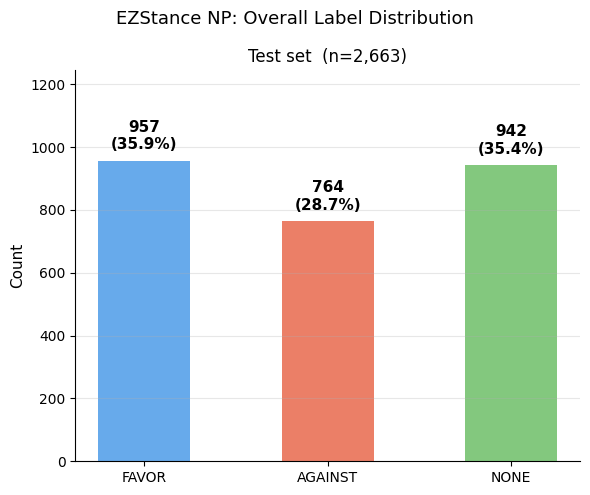

In [161]:
_te = pd.read_csv("../data_in/ezstance/ezstance_test.csv")
_LBLS   = ["FAVOR", "AGAINST", "NONE"]
_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

def _lc(df):
    vc = df["stance_label_original"].str.upper().str.strip().value_counts()
    return {l: vc.get(l, 0) for l in _LBLS}

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("EZStance NP: Overall Label Distribution", fontsize=13)
counts = _lc(_te)
total  = sum(counts.values())
vals   = [counts[l] for l in _LBLS]
bars   = ax.bar(_LBLS, vals, color=[_COLORS[l] for l in _LBLS], alpha=0.85, width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
            f"{v:,}\n({v/total:.1%})", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylim(0, max(vals)*1.3)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Test set  (n={len(_te):,})", fontsize=12)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4: Pooled Metrics

In [162]:
best_idx  = llm_df["3class_macro_f1"].idxmax()
worst_idx = llm_df["3class_macro_f1"].idxmin()

print("=== Pooled 3-class Macro F1 (all model×prompt) ===")
print(f"  Mean:  {llm_df['3class_macro_f1'].mean():.4f}")
print(f"  Best:  {llm_df.loc[best_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[best_idx, 'model']} | {llm_df.loc[best_idx, 'prompt']})")
print(f"  Worst: {llm_df.loc[worst_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[worst_idx, 'model']} | {llm_df.loc[worst_idx, 'prompt']})")
print()
print(f"Paper best (BART-MNLI-ep, M→N): {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot):       {CHATGPT_F3:.4f}")

=== Pooled 3-class Macro F1 (all model×prompt) ===
  Mean:  0.5684
  Best:  0.6441  (Qwen3-14B | task_definition_scale)
  Worst: 0.4017  (Nemotron-Mini-4B-Instruct | task_definition_scale)

Paper best (BART-MNLI-ep, M→N): 0.6690
Paper ChatGPT (zero-shot):       0.6040


## Step 5: Chart — 3-class Macro F1 vs Paper Baselines

Baseline = EZ-STANCE paper Table 7 (M→N, trained on mixed, tested on noun-phrase targets).
Fine-tuned best: **BART-MNLI-eₚ = 0.669**. Zero-shot LLMs from paper: ChatGPT 0.604, LLaMA2 0.436.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19372/830237172.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))


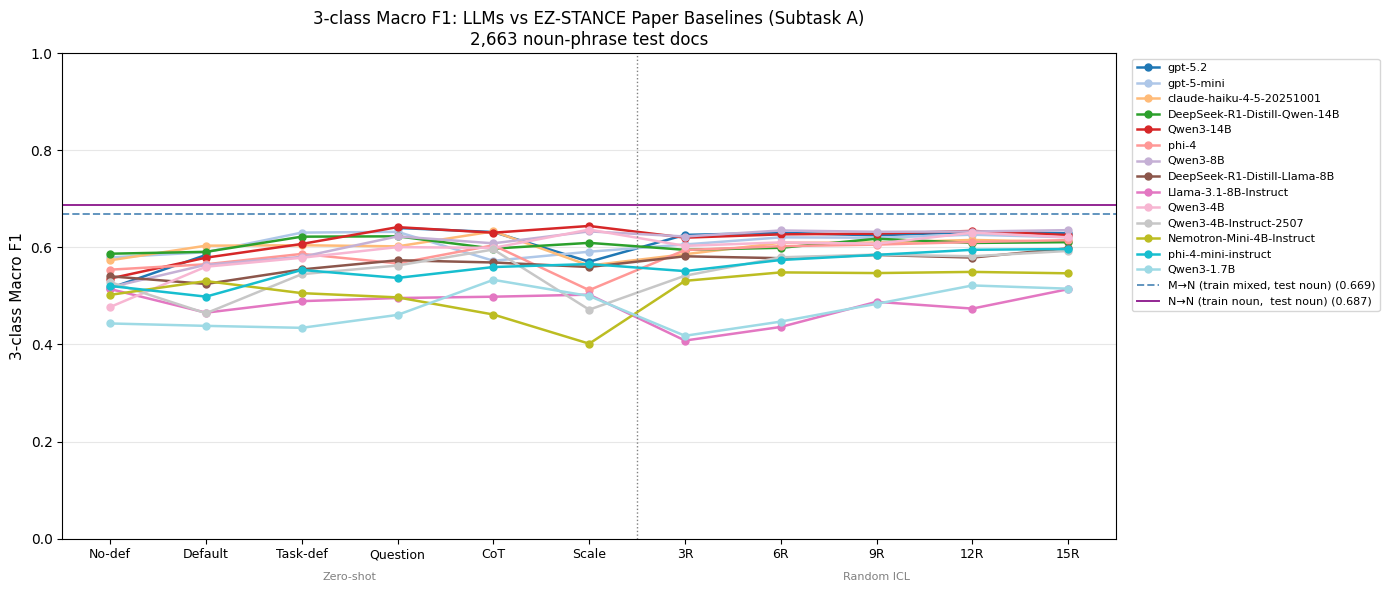

In [163]:
available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]
x_pos    = list(range(len(available_prompts)))

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))

fig, ax = plt.subplots(figsize=(max(14, len(available_prompts) * 1.1), 6))

for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y = [mdf.loc[p, "3class_macro_f1"] if p in mdf.index else float("nan")
         for p in available_prompts]
    short = model.split("/")[-1] if "/" in model else model
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5,
            label=short, color=cmap(i))

# Best supervised baseline per training/testing configuration — Table 7, Subtask A
key_baselines = [
    ("M\u2192N (train mixed, test noun)", 0.669, "steelblue", "--"),
    ("N\u2192N (train noun,  test noun)", 0.687, "purple",    "-"),
]
for name, val, col, ls in key_baselines:
    ax.axhline(val, color=col, linestyle=ls, linewidth=1.4, alpha=0.85,
               label=f"{name} ({val:.3f})")

if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    sx = (available_prompts.index("task_definition_scale") +
          available_prompts.index("few_shot_3")) / 2
    ax.axvline(sx, color="grey", linestyle=":", linewidth=1)
    for j, lbl in enumerate(["Zero-shot", "Random ICL"]):
        mid = ([-0.5, sx][j] + [sx, len(available_prompts) - 0.5][j]) / 2
        ax.text(mid, -0.085, lbl, ha="center", fontsize=8, color="grey",
                transform=ax.get_xaxis_transform())

ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title(
    "3-class Macro F1: LLMs vs EZ-STANCE Paper Baselines (Subtask A)\n2,663 noun-phrase test docs",
    fontsize=12,
)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Numerical Tables

**Table I** — per-model summary: mean / best / std F3 across all prompts.
**Table II** — per-model × prompt: F3 and per-class F1.

In [164]:
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f3=("3class_macro_f1", "mean"),
        best_f3=("3class_macro_f1", "max"),
        std_f3 =("3class_macro_f1", "std"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
summary["model_short"] = summary["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table I: Per-model Summary ===")
print(f"{'Model':<42} {'mean_F3':>8} {'best_F3':>8} {'std_F3':>8}")
print("-" * 72)
for _, r in summary.iterrows():
    print(f"{r['model_short']:<42} {r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {r['std_f3']:>8.4f}")
print()
print(f"Paper best (BART-MNLI-ep, M→N):   {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot):         {CHATGPT_F3:.4f}")

print("\n=== Table II: Per-model × Prompt ===")
tbl = llm_df.copy()
tbl["prompt_rank"]  = tbl["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})
tbl["model_short"]  = tbl["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
tbl = tbl.sort_values(["model_short", "prompt_rank"])
cols = ["model_short", "prompt", "3class_macro_f1", "f_favor", "f_against", "f_none"]
print(tbl[cols].to_string(index=False, float_format="{:.4f}".format))

=== Table I: Per-model Summary ===
Model                                       mean_F3  best_F3   std_F3
------------------------------------------------------------------------
Qwen3-14B                                    0.6156   0.6441   0.0320
gpt-5.2                                      0.6084   0.6400   0.0395
gpt-5-mini                                   0.6080   0.6320   0.0214
Qwen3-8B                                     0.6076   0.6354   0.0381
DeepSeek-R1-Distill-Qwen-14B                 0.6055   0.6228   0.0125
claude-haiku-4-5-20251001                    0.6010   0.6329   0.0199
Qwen3-4B                                     0.5931   0.6366   0.0441
phi-4                                        0.5834   0.6149   0.0312
DeepSeek-R1-Distill-Llama-8B                 0.5675   0.5981   0.0212
phi-4-mini-instruct                          0.5578   0.5966   0.0305
Qwen3-4B-Instruct-2507                       0.5498   0.5956   0.0460
Nemotron-Mini-4B-Instruct                    0.5110 

## Step 7: Per-class Precision / Recall / F1 — by Prompt

3 × 3 grid: **rows** = class (FAVOR, AGAINST, NONE), **columns** = metric (Precision, Recall, F1).
No class-level paper baseline available for this M→N setting.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19372/3355884926.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", len(models))


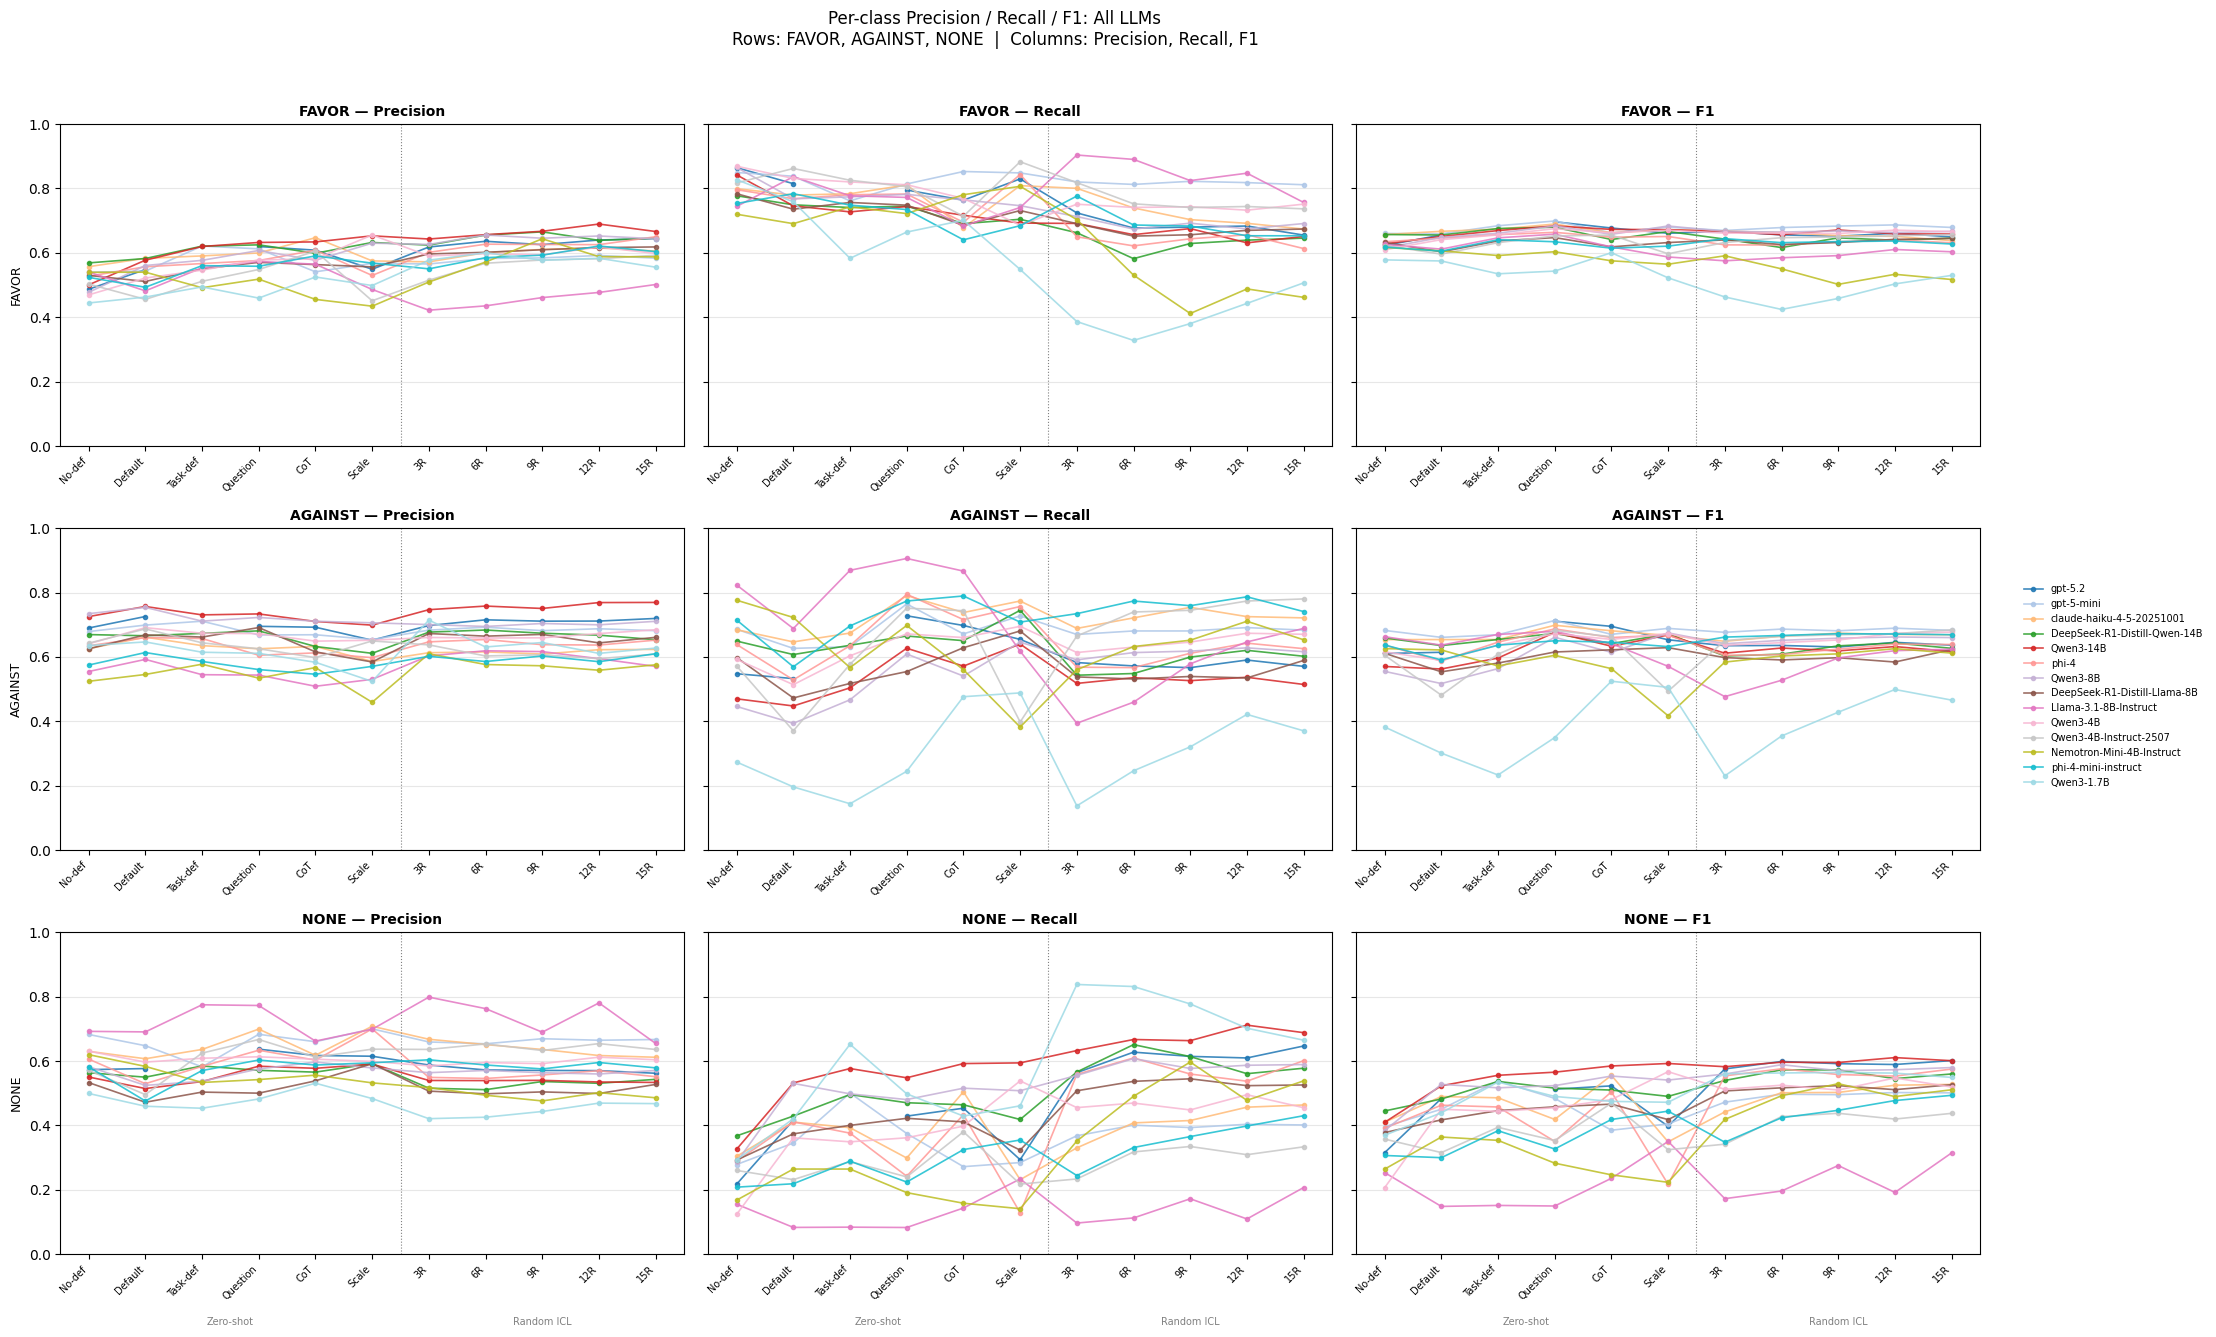

In [165]:
METRICS = [("p", "Precision"), ("r", "Recall"), ("f", "F1")]

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", len(models))

fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (metric_key, metric_label) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{metric_key}_{cls.lower()}"

        for i, model in enumerate(models):
            mdf   = llm_df[llm_df["model"] == model].set_index("prompt")
            y     = [mdf.loc[p, col_name] if p in mdf.index else float("nan")
                     for p in available_prompts]
            short = model.split("/")[-1] if "/" in model else model
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=short, color=cmap(i), alpha=0.85)

        if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
            sx = (available_prompts.index("task_definition_scale") +
                  available_prompts.index("few_shot_3")) / 2
            ax.axvline(sx, color="grey", linestyle=":", linewidth=0.8)

        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {metric_label}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9)

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, leg_labels, bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=7, frameon=False)

boundaries = [-0.5]
if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    boundaries.append((available_prompts.index("task_definition_scale") +
                       available_prompts.index("few_shot_3")) / 2)
boundaries.append(len(available_prompts) - 0.5)
group_names = ["Zero-shot", "Random ICL"]
for col_idx in range(3):
    ax = axes[2][col_idx]
    for gi, glbl in enumerate(group_names):
        if gi < len(boundaries) - 1:
            mid = (boundaries[gi] + boundaries[gi + 1]) / 2
            ax.text(mid, -0.22, glbl, ha="center", fontsize=7, color="grey",
                    transform=ax.get_xaxis_transform())

fig.suptitle(
    "Per-class Precision / Recall / F1: All LLMs\n"
    "Rows: FAVOR, AGAINST, NONE  |  Columns: Precision, Recall, F1",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 8: Per-class F1 — Model Comparison (mean ± std across prompts)

Three panels (FAVOR / AGAINST / NONE). Bar = mean class F1 across all prompts. Error bar = std.
No class-level paper baseline available for M→N setting.

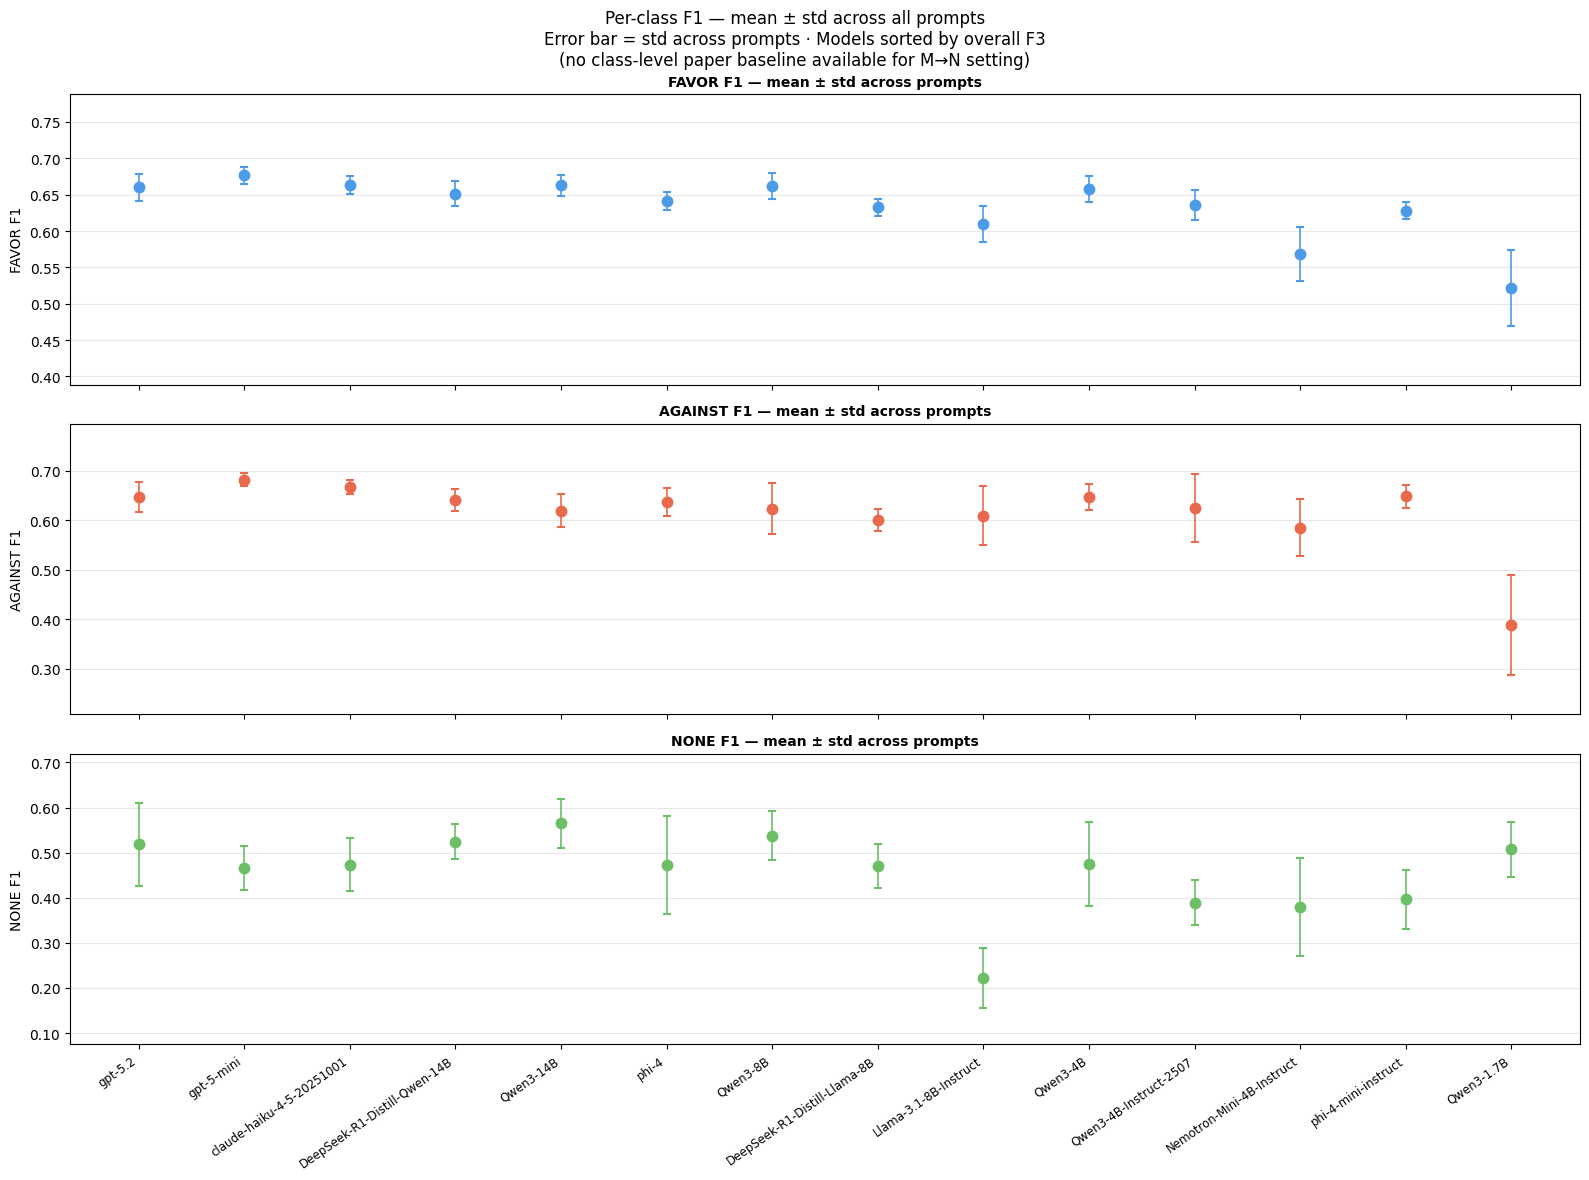

In [166]:
CLASS_COLS  = {"FAVOR": "f_favor", "AGAINST": "f_against", "NONE": "f_none"}
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C",   "NONE": "#6DBF67"}

model_order = _ordered_models(llm_df)
model_labels = [m.split("/")[-1] if "/" in m else m for m in model_order]
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax    = axes[row_idx]
    col   = CLASS_COLS[cls]
    color = CLASS_COLOR[cls]

    means, stds = [], []
    for model in model_order:
        vals = llm_df[llm_df["model"] == model][col].values
        means.append(vals.mean())
        stds.append(vals.std())
    means = np.array(means)
    stds  = np.array(stds)

    ax.errorbar(x, means, yerr=stds, fmt="o", markersize=7,
                color=color, markeredgecolor=color, markeredgewidth=1.5,
                ecolor=color, elinewidth=1.2, capsize=3, zorder=3)

    ax.set_ylabel(f"{cls} F1", fontsize=10)
    ax.set_ylim(max(0, (means - stds).min() - 0.08), min(1, (means + stds).max() + 0.1))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — mean ± std across prompts", fontsize=10, fontweight="bold")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(model_labels, rotation=35, ha="right", fontsize=8.5)

fig.suptitle(
    "Per-class F1 — mean ± std across all prompts\n"
    "Error bar = std across prompts · Models sorted by overall F3\n"
    "(no class-level paper baseline available for M→N setting)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 9: Precision vs Recall Scatter — per class

Each dot = one model × prompt combination, coloured by model.
Dashed diagonal = P = R.
No paper-baseline stars (class-level not available for M→N).

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19372/2724388977.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap("tab20", len(models))


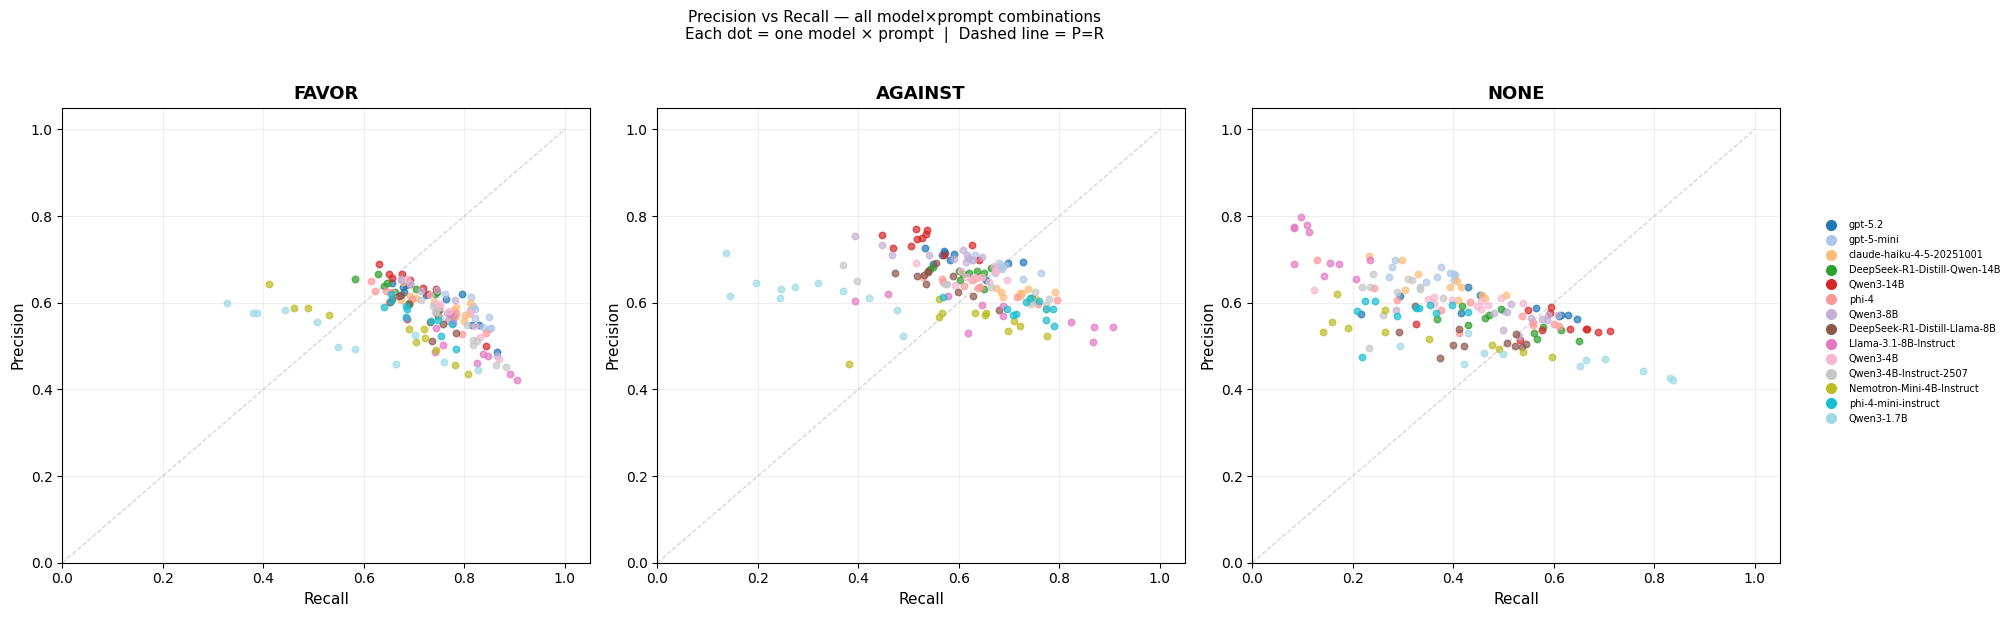

In [167]:
models      = _ordered_models(llm_df)
cmap        = plt.cm.get_cmap("tab20", len(models))
model_color = {m: cmap(i) for i, m in enumerate(models)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col_idx, cls in enumerate(CLASSES):
    ax    = axes[col_idx]
    p_col = f"p_{cls.lower()}"
    r_col = f"r_{cls.lower()}"

    ax.plot([0, 1], [0, 1], color="lightgrey", linestyle="--", linewidth=0.9, zorder=0)

    for model in models:
        mdf   = llm_df[llm_df["model"] == model]
        short = model.split("/")[-1] if "/" in model else model
        ax.scatter(mdf[r_col], mdf[p_col],
                   color=model_color[model], s=22, alpha=0.7, zorder=2, label=short)

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall",    fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(cls, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", linestyle="None",
                          color=model_color[m], markersize=7,
                          label=m.split("/")[-1] if "/" in m else m)
           for m in models]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc="center left",
           fontsize=7, frameon=False)

fig.suptitle(
    "Precision vs Recall — all model×prompt combinations\n"
    "Each dot = one model × prompt  |  Dashed line = P=R",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 10: Predicted vs Gold Distribution — per class, per model across all prompts

Dots = per-prompt predicted fraction. Diamond = mean across prompts. Red line = gold test fraction.

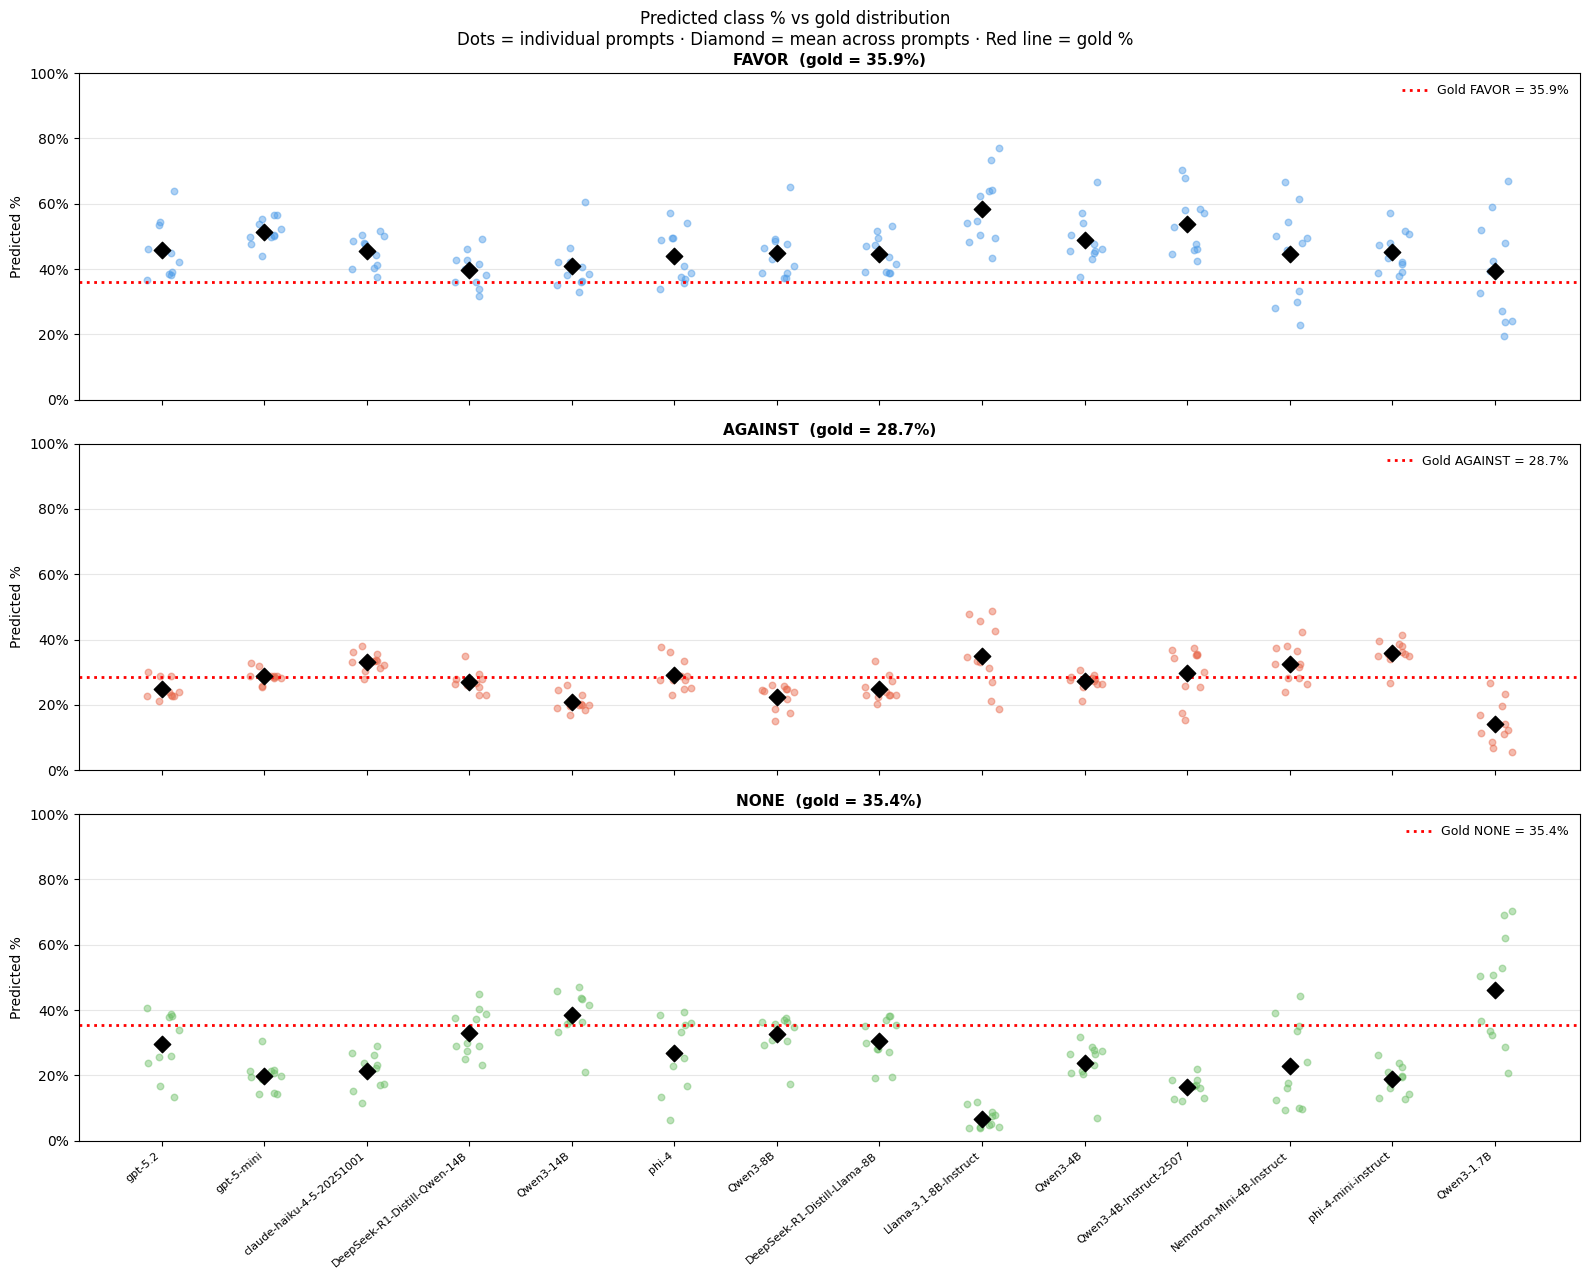

In [168]:
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2663"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) == 0:
        continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({
        "model": model, "prompt": prompt,
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
        "model_short":  model.split("/")[-1] if "/" in model else model,
    })

dist_df = pd.DataFrame(dist_rows)

CLASS_COLS_D = {"FAVOR": "pred_favor", "AGAINST": "pred_against", "NONE": "pred_none"}
llm_models_sorted = _ordered_models(dist_df, "model_short")
x = np.arange(len(llm_models_sorted))
model_idx = {m: i for i, m in enumerate(llm_models_sorted)}

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax       = axes[row_idx]
    col      = CLASS_COLS_D[cls]
    gold_pct = GOLD_DIST[cls]
    color    = CLASS_COLORS[cls]

    for model in llm_models_sorted:
        mdf = dist_df[dist_df["model_short"] == model]
        xi  = model_idx[model]
        jitter = (np.random.default_rng(42).random(len(mdf)) - 0.5) * 0.35
        ax.scatter(xi + jitter, mdf[col], alpha=0.45, s=22, color=color, zorder=2)
        ax.scatter(xi, mdf[col].mean(), marker="D", s=70, color="black", zorder=4)

    ax.axhline(gold_pct, color="red", linestyle=":", linewidth=2,
               label=f"Gold {cls} = {gold_pct:.1%}")

    ax.set_ylabel("Predicted %", fontsize=10)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(f"{cls}  (gold = {gold_pct:.1%})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(llm_models_sorted, rotation=40, ha="right", fontsize=8)

fig.suptitle(
    "Predicted class % vs gold distribution\n"
    "Dots = individual prompts · Diamond = mean across prompts · Red line = gold %",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 11: Confusion Transition Analysis — Key Misclassifications

Six off-diagonal transitions: AGAINST→NONE, AGAINST→FAVOR, FAVOR→AGAINST, FAVOR→NONE, NONE→FAVOR, NONE→AGAINST.
**Table A** — per model, averaged across prompts. **Heatmap** — all model×prompt rows.

=== Table A: Confusion Transitions — per model (mean across all prompts) ===
Model                                   FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5.2                                      74.9%            7.3%           17.8%           19.1%           60.4%           20.5%           37.7%           13.6%           48.7% 
gpt-5-mini                                   82.3%            8.3%            9.5%           19.8%           68.3%           11.9%           45.9%           17.5%           36.6% 
claude-haiku-4-5-20251001                    75.2%           12.7%           12.1%           16.2%           72.0%           11.8%           39.1%           22.6%           38.3% 
DeepSeek-R1-Distill-Qwe

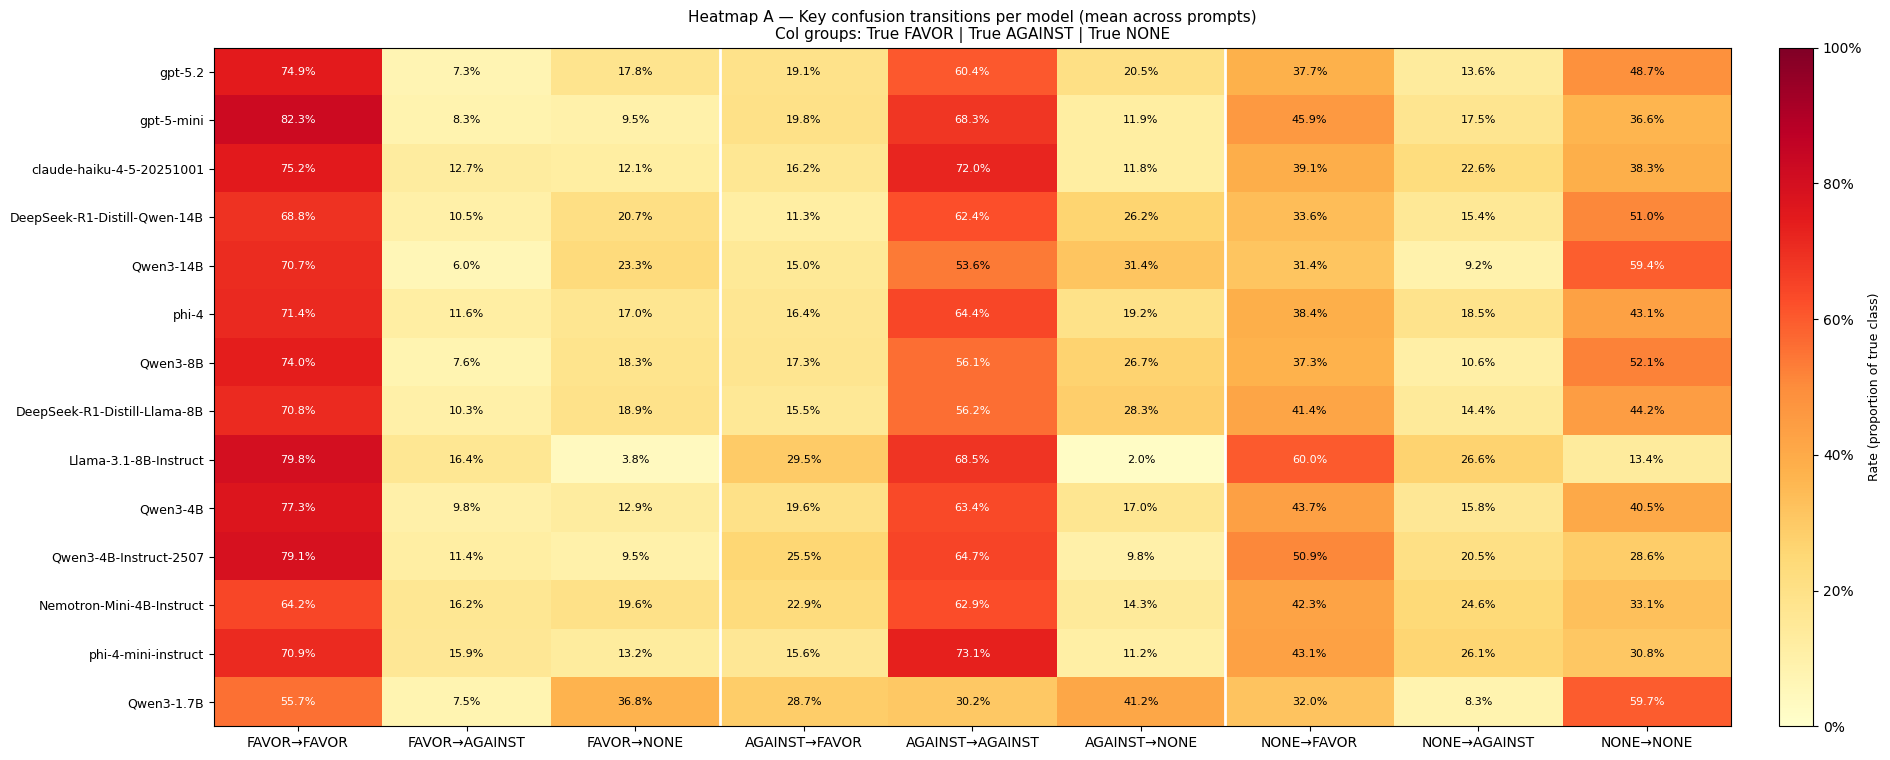


=== Table B: Confusion Transitions — per model × prompt ===
Model · Prompt                                       FAVOR→FAVOR   FAVOR→AGAINST      FAVOR→NONE   AGAINST→FAVOR AGAINST→AGAINST    AGAINST→NONE      NONE→FAVOR    NONE→AGAINST       NONE→NONE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DeepSeek-R1-Distill-Llama-8B · No-def                     78.4%           10.9%           10.8%           22.1%           59.8%           18.1%           52.7%           18.1%           29.2% 
DeepSeek-R1-Distill-Llama-8B · Default                    73.6%            7.4%           19.0%           25.0%           47.3%           27.7%           51.2%           11.5%           37.4% 
DeepSeek-R1-Distill-Llama-8B · Task-def                   75.7%            8.4%           16.0%           19.7%           51.8%           28.6%           47.0%        

In [169]:
KEY_TRANS = [
    "FAVOR→FAVOR",   "FAVOR→AGAINST",   "FAVOR→NONE",
    "AGAINST→FAVOR", "AGAINST→AGAINST", "AGAINST→NONE",
    "NONE→FAVOR",    "NONE→AGAINST",    "NONE→NONE",
]

cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2663"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"]  = df["original_stance"].astype(str).str.upper().str.strip()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: (lambda s: CANON_MAP.get(s, s))(str(x).upper().strip())
        if pd.notna(x) else None
    )
    df = df[df["original_stance"].isin(CLASSES) & df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue

    yt, yp  = df["original_stance"].tolist(), df["predicted_stance"].tolist()
    cm      = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    short   = model.split("/")[-1] if "/" in model else model

    row = {"model": model, "prompt": prompt, "model_short": short}
    for ri, tc in enumerate(CLASSES):
        for ci, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_norm[ri, ci]
    cm_rows.append(row)

cm_df = pd.DataFrame(cm_rows)
cm_df["prompt_rank"] = cm_df["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})

mean_cm = (
    cm_df.groupby("model_short")[KEY_TRANS].mean()
    .reindex([m for m in MODEL_ORDER if m in cm_df["model_short"].unique()])
)

print("=== Table A: Confusion Transitions — per model (mean across all prompts) ===")
print(f"{'Model':<35}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (35 + 16 * len(KEY_TRANS)))
for model, row in mean_cm.iterrows():
    print(f"{model:<35}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))

fig, ax = plt.subplots(figsize=(19, max(5, len(mean_cm) * 0.55)))
data_a = mean_cm[KEY_TRANS].values
im = ax.imshow(data_a, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)

ax.set_xticks(range(len(KEY_TRANS)))
ax.set_xticklabels(KEY_TRANS, fontsize=10)
ax.set_yticks(range(len(mean_cm)))
ax.set_yticklabels(mean_cm.index, fontsize=9)

for sep in [2.5, 5.5]:
    ax.axvline(sep, color="white", linewidth=2)

for i in range(data_a.shape[0]):
    for j in range(data_a.shape[1]):
        ax.text(j, i, f"{data_a[i,j]:.1%}", ha="center", va="center", fontsize=8,
                color="white" if data_a[i,j] > 0.55 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label("Rate (proportion of true class)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(
    "Heatmap A — Key confusion transitions per model (mean across prompts)\n"
    "Col groups: True FAVOR | True AGAINST | True NONE",
    fontsize=11,
)
plt.tight_layout()
plt.show()

cm_sorted = cm_df.sort_values(["model_short", "prompt_rank"])
cm_sorted["row_label"] = (
    cm_sorted["model_short"] + " · " +
    cm_sorted["prompt"].map(PROMPT_LABELS_CHART)
)

print("\n=== Table B: Confusion Transitions — per model × prompt ===")
print(f"{'Model · Prompt':<48}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (48 + 16 * len(KEY_TRANS)))
prev = None
for _, row in cm_sorted.iterrows():
    if prev and row["model_short"] != prev:
        print()
    print(f"{row['row_label']:<48}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))
    prev = row["model_short"]

In [170]:
# ── Tables for Heatmap A & B ─────────────────────────────────────────
print("=== Heatmap A: per-model confusion transitions (mean across prompts) ===")
display(mean_cm[KEY_TRANS].round(3))
print(mean_cm[KEY_TRANS].round(3).to_csv())

print("\n=== Heatmap B: per model×prompt confusion transitions ===")
_hm_b = cm_sorted.set_index("row_label")[KEY_TRANS].round(3)
display(_hm_b)
print(_hm_b.to_csv())


=== Heatmap A: per-model confusion transitions (mean across prompts) ===


,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
model_short,,,,,,,,,
gpt-5.2,0.749,0.073,0.178,0.191,0.604,0.205,0.377,0.136,0.487
gpt-5-mini,0.823,0.083,0.095,0.198,0.683,0.119,0.459,0.175,0.366
claude-haiku-4-5-20251001,0.752,0.127,0.121,0.162,0.720,0.118,0.391,0.226,0.383
DeepSeek-R1-Distill-Qwen-14B,0.688,0.105,0.207,0.113,0.624,0.262,0.336,0.154,0.510
Qwen3-14B,0.707,0.060,0.233,0.150,0.536,0.314,0.314,0.092,0.594
phi-4,0.714,0.116,0.170,0.164,0.644,0.192,0.384,0.185,0.431
Qwen3-8B,0.740,0.076,0.183,0.173,0.561,0.267,0.373,0.106,0.521
DeepSeek-R1-Distill-Llama-8B,0.708,0.103,0.189,0.155,0.562,0.283,0.414,0.144,0.442
Llama-3.1-8B-Instruct,0.798,0.164,0.038,0.295,0.685,0.020,0.600,0.266,0.134


model_short,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
gpt-5.2,0.749,0.073,0.178,0.191,0.604,0.205,0.377,0.136,0.487
gpt-5-mini,0.823,0.083,0.095,0.198,0.683,0.119,0.459,0.175,0.366
claude-haiku-4-5-20251001,0.752,0.127,0.121,0.162,0.72,0.118,0.391,0.226,0.383
DeepSeek-R1-Distill-Qwen-14B,0.688,0.105,0.207,0.113,0.624,0.262,0.336,0.154,0.51
Qwen3-14B,0.707,0.06,0.233,0.15,0.536,0.314,0.314,0.092,0.594
phi-4,0.714,0.116,0.17,0.164,0.644,0.192,0.384,0.185,0.431
Qwen3-8B,0.74,0.076,0.183,0.173,0.561,0.267,0.373,0.106,0.521
DeepSeek-R1-Distill-Llama-8B,0.708,0.103,0.189,0.155,0.562,0.283,0.414,0.144,0.442
Llama-3.1-8B-Instruct,0.798,0.164,0.038,0.295,0.685,0.02,0.6,0.266,0.134
Qwen3-4B,0.773,0.098,0.129,0.196,0.634,0.17,0.437,0.158,0.405
Qwen3-4B-Instruct-2507,0.791,0.114,0.095,0.255,0.647,0.098,0.509,0.205,0.286
Nemotron-Mini-4B-Instruct,0.642,0.162,0.196,0.229,0.629,0.143,0.423,0.246,0.331
phi-4-mini-instruct,0.709,0.

,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
row_label,,,,,,,,,
DeepSeek-R1-Distill-Llama-8B · No-def,0.784,0.109,0.108,0.221,0.598,0.181,0.527,0.181,0.292
DeepSeek-R1-Distill-Llama-8B · Default,0.736,0.074,0.190,0.250,0.473,0.277,0.512,0.115,0.374
DeepSeek-R1-Distill-Llama-8B · Task-def,0.757,0.084,0.160,0.197,0.518,0.286,0.470,0.130,0.400
DeepSeek-R1-Distill-Llama-8B · Question,0.748,0.079,0.172,0.142,0.554,0.304,0.458,0.120,0.422
DeepSeek-R1-Distill-Llama-8B · CoT,0.685,0.140,0.175,0.155,0.629,0.217,0.414,0.175,0.411
...,...,...,...,...,...,...,...,...,...
phi-4-mini-instruct · 3R,0.776,0.143,0.080,0.169,0.734,0.097,0.507,0.248,0.244
phi-4-mini-instruct · 6R,0.687,0.165,0.148,0.126,0.774,0.101,0.393,0.276,0.331
phi-4-mini-instruct · 9R,0.683,0.148,0.168,0.119,0.759,0.122,0.380,0.255,0.365


row_label,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
DeepSeek-R1-Distill-Llama-8B · No-def,0.784,0.109,0.108,0.221,0.598,0.181,0.527,0.181,0.292
DeepSeek-R1-Distill-Llama-8B · Default,0.736,0.074,0.19,0.25,0.473,0.277,0.512,0.115,0.374
DeepSeek-R1-Distill-Llama-8B · Task-def,0.757,0.084,0.16,0.197,0.518,0.286,0.47,0.13,0.4
DeepSeek-R1-Distill-Llama-8B · Question,0.748,0.079,0.172,0.142,0.554,0.304,0.458,0.12,0.422
DeepSeek-R1-Distill-Llama-8B · CoT,0.685,0.14,0.175,0.155,0.629,0.217,0.414,0.175,0.411
DeepSeek-R1-Distill-Llama-8B · Scale,0.731,0.164,0.104,0.175,0.681,0.144,0.451,0.226,0.323
DeepSeek-R1-Distill-Llama-8B · 3R,0.691,0.088,0.222,0.13,0.538,0.332,0.369,0.123,0.507
DeepSeek-R1-Distill-Llama-8B · 6R,0.652,0.098,0.25,0.115,0.531,0.353,0.345,0.118,0.537
DeepSeek-R1-Distill-Llama-8B · 9R,0.656,0.102,0.241,0.102,0.539,0.359,0.344,0.111,0.545
DeepSeek-R1-Distill-Llama-8B · 12R,0.67,0.096,0.234,0.11,0.535,0.355,0

## Step 12: Model Ranking Table (F3)

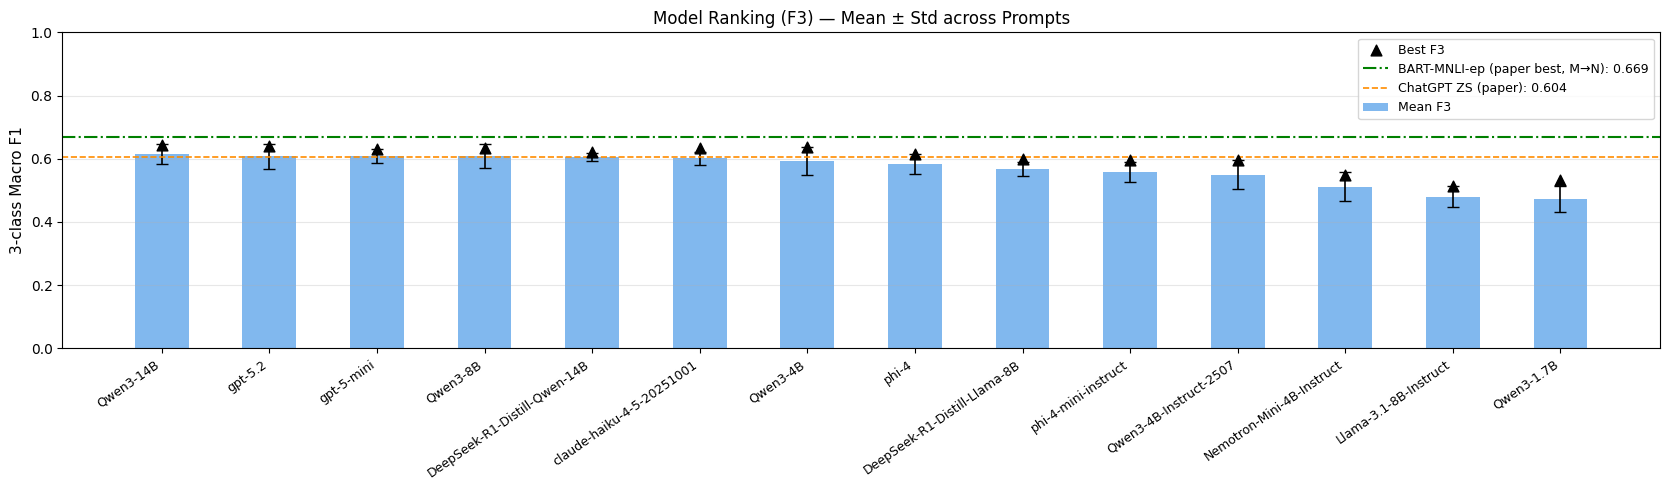


=== Ranking Table ===
                 model_short mean_f3 best_f3 std_f3 mean_f1_favor mean_f1_against mean_f1_none
                   Qwen3-14B  0.6156  0.6441 0.0320        0.6626          0.6194       0.5649
                     gpt-5.2  0.6084  0.6400 0.0395        0.6598          0.6467       0.5186
                  gpt-5-mini  0.6080  0.6320 0.0214        0.6765          0.6818       0.4658
                    Qwen3-8B  0.6076  0.6354 0.0381        0.6616          0.6235       0.5377
DeepSeek-R1-Distill-Qwen-14B  0.6055  0.6228 0.0125        0.6515          0.6409       0.5243
   claude-haiku-4-5-20251001  0.6010  0.6329 0.0199        0.6631          0.6666       0.4731
                    Qwen3-4B  0.5931  0.6366 0.0441        0.6576          0.6476       0.4740
                       phi-4  0.5834  0.6149 0.0312        0.6414          0.6363       0.4725
DeepSeek-R1-Distill-Llama-8B  0.5675  0.5981 0.0212        0.6323          0.6004       0.4696
         phi-4-mini-instruc

In [171]:
ranking = (
    llm_df.groupby("model")
    .agg(
        mean_f3        =("3class_macro_f1", "mean"),
        best_f3        =("3class_macro_f1", "max"),
        std_f3         =("3class_macro_f1", "std"),
        mean_f1_favor  =("f_favor",         "mean"),
        mean_f1_against=("f_against",       "mean"),
        mean_f1_none   =("f_none",          "mean"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
ranking["model_short"] = ranking["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
ranking["mean_f3"]     = ranking["mean_f3"].map("{:.4f}".format)
ranking["best_f3"]     = ranking["best_f3"].map("{:.4f}".format)
ranking["std_f3"]      = ranking["std_f3"].map("{:.4f}".format)
ranking["mean_f1_favor"]   = ranking["mean_f1_favor"].map("{:.4f}".format)
ranking["mean_f1_against"] = ranking["mean_f1_against"].map("{:.4f}".format)
ranking["mean_f1_none"]    = ranking["mean_f1_none"].map("{:.4f}".format)

n = len(ranking)
x = np.arange(n)
mean_f3_num = ranking["mean_f3"].astype(float)
best_f3_num = ranking["best_f3"].astype(float)
std_f3_num  = ranking["std_f3"].astype(float)

fig, ax = plt.subplots(figsize=(max(12, n * 1.2), 5))
ax.bar(x, mean_f3_num, width=0.5, color="#4C9BE8", alpha=0.7, label="Mean F3")
ax.errorbar(x, mean_f3_num, yerr=std_f3_num,
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.scatter(x, best_f3_num, marker="^", s=60, color="black", zorder=5, label="Best F3")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.5,
           label=f"BART-MNLI-ep (paper best, M→N): {BEST_PAPER_F3}")
ax.axhline(CHATGPT_F3, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"ChatGPT ZS (paper): {CHATGPT_F3}")
ax.set_xticks(x)
ax.set_xticklabels(ranking["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Model Ranking (F3) — Mean ± Std across Prompts", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Ranking Table ===")
cols = ["model_short","mean_f3","best_f3","std_f3","mean_f1_favor","mean_f1_against","mean_f1_none"]
print(ranking[cols].to_string(index=False))

## Step 13: Prompt Sensitivity

**Table 13a** — per model: std F3, best/worst prompt, F3 range.
**Plot 13b** — F3 range per model (sorted by range descending).
**Table 13c** — per prompt: mean F3 across all models.

=== Table 13a: Per-model Prompt Sensitivity ===
                 model_short  std_f3  best_f3  worst_f3  range_f3                  best_prompt                 worst_prompt
                    Qwen3-4B  0.0441   0.6366    0.4772    0.1594        task_definition_scale default_no_label_definitions
   Nemotron-Mini-4B-Instruct  0.0457   0.5495    0.4017    0.1478                  few_shot_12        task_definition_scale
      Qwen3-4B-Instruct-2507  0.0460   0.5956    0.4643    0.1313                          cot                      default
                     gpt-5.2  0.0395   0.6400    0.5163    0.1237                     question default_no_label_definitions
                    Qwen3-8B  0.0381   0.6354    0.5179    0.1175                  few_shot_15 default_no_label_definitions
                  Qwen3-1.7B  0.0400   0.5331    0.4179    0.1152                          cot                   few_shot_3
                   Qwen3-14B  0.0320   0.6441    0.5359    0.1082        task_defini

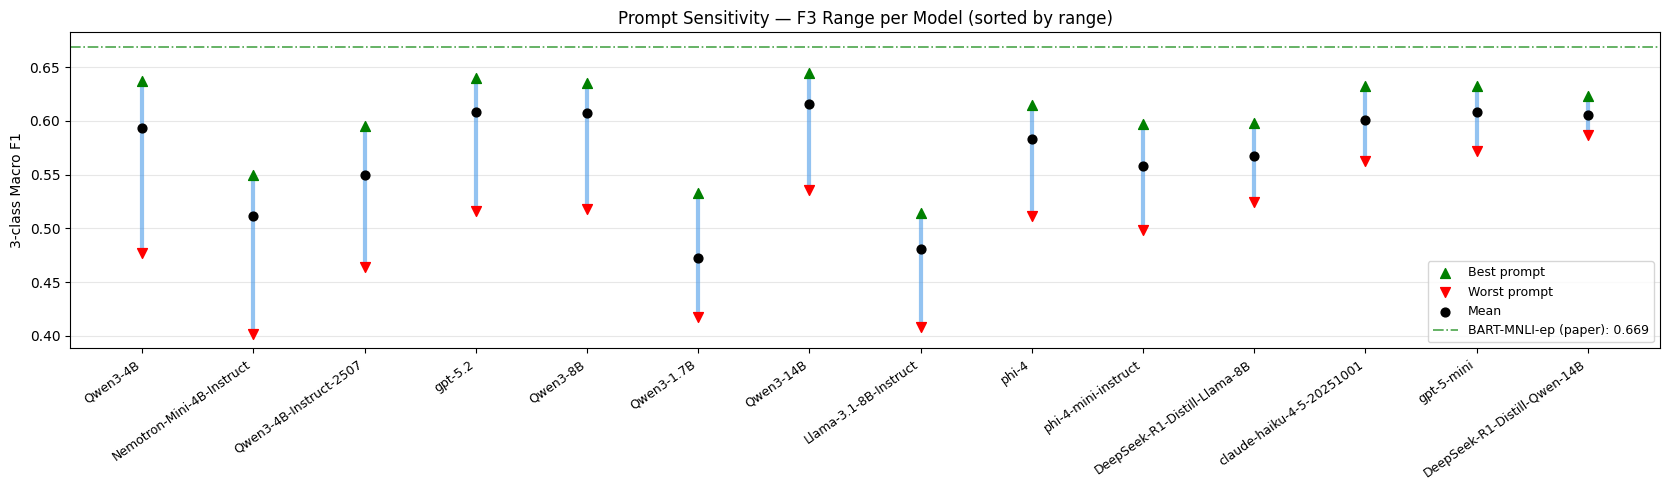


=== Table 13c: Per-prompt mean F3 across all models ===
                              mean_f3  std_f3  best_f3       group
prompt                                                            
default_no_label_definitions   0.5279  0.0392   0.5869   Zero-shot
default                        0.5399  0.0540   0.6035   Zero-shot
task_definition                0.5609  0.0566   0.6304   Zero-shot
question                       0.5754  0.0588   0.6416   Zero-shot
cot                            0.5781  0.0509   0.6329   Zero-shot
task_definition_scale          0.5543  0.0698   0.6441   Zero-shot
few_shot_3                     0.5631  0.0700   0.6257  Random ICL
few_shot_6                     0.5783  0.0628   0.6348  Random ICL
few_shot_9                     0.5870  0.0485   0.6321  Random ICL
few_shot_12                    0.5922  0.0479   0.6339  Random ICL
few_shot_15                    0.5951  0.0405   0.6354  Random ICL


In [172]:
ZERO_SHOT_PROMPTS  = ["default_no_label_definitions", "default", "task_definition",
                       "question", "cot", "task_definition_scale"]
RANDOM_ICL_PROMPTS = ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"]
PROMPT_GROUP = {**{p: "Zero-shot" for p in ZERO_SHOT_PROMPTS},
                **{p: "Random ICL" for p in RANDOM_ICL_PROMPTS}}

sens_rows = []
for model in _ordered_models(llm_df):
    mdf = llm_df[llm_df["model"] == model]
    sens_rows.append({
        "model":        model,
        "mean_f3":      mdf["3class_macro_f1"].mean(),
        "std_f3":       mdf["3class_macro_f1"].std(),
        "best_f3":      mdf["3class_macro_f1"].max(),
        "worst_f3":     mdf["3class_macro_f1"].min(),
        "range_f3":     mdf["3class_macro_f1"].max() - mdf["3class_macro_f1"].min(),
        "best_prompt":  mdf.loc[mdf["3class_macro_f1"].idxmax(), "prompt"],
        "worst_prompt": mdf.loc[mdf["3class_macro_f1"].idxmin(), "prompt"],
    })
sens_df = pd.DataFrame(sens_rows).sort_values("range_f3", ascending=False)
sens_df["model_short"] = sens_df["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table 13a: Per-model Prompt Sensitivity ===")
cols_s = ["model_short", "std_f3", "best_f3", "worst_f3", "range_f3", "best_prompt", "worst_prompt"]
print(sens_df[cols_s].to_string(index=False, float_format="{:.4f}".format))

n = len(sens_df)
x = np.arange(n)
fig, ax = plt.subplots(figsize=(max(10, n * 1.2), 5))
ax.vlines(x, sens_df["worst_f3"], sens_df["best_f3"],
          color="#4C9BE8", linewidth=3, alpha=0.6)
ax.scatter(x, sens_df["best_f3"],  marker="^", color="green",  s=50, zorder=5, label="Best prompt")
ax.scatter(x, sens_df["worst_f3"], marker="v", color="red",    s=50, zorder=5, label="Worst prompt")
ax.scatter(x, sens_df["mean_f3"],  marker="o", color="black",  s=40, zorder=6, label="Mean")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.2, alpha=0.7,
           label=f"BART-MNLI-ep (paper): {BEST_PAPER_F3}")
ax.set_xticks(x)
ax.set_xticklabels(sens_df["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("3-class Macro F1")
ax.set_title("Prompt Sensitivity — F3 Range per Model (sorted by range)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Table 13c: Per-prompt mean F3 across all models ===")
avail = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
prom_tbl = (
    llm_df[llm_df["prompt"].isin(avail)]
    .groupby("prompt")["3class_macro_f1"]
    .agg(["mean", "std", "max"])
    .reindex(avail)
    .rename(columns={"mean": "mean_f3", "std": "std_f3", "max": "best_f3"})
)
prom_tbl["group"] = prom_tbl.index.map(PROMPT_GROUP)
print(prom_tbl.round(4).to_string())

## Step 14: F3 by Prompt Family — Grouped Bar Chart

Three families: **Label Defs** (zero-shot label variants), **Reasoning** (question / CoT / scale), **Random ICL** (3–15 shots).

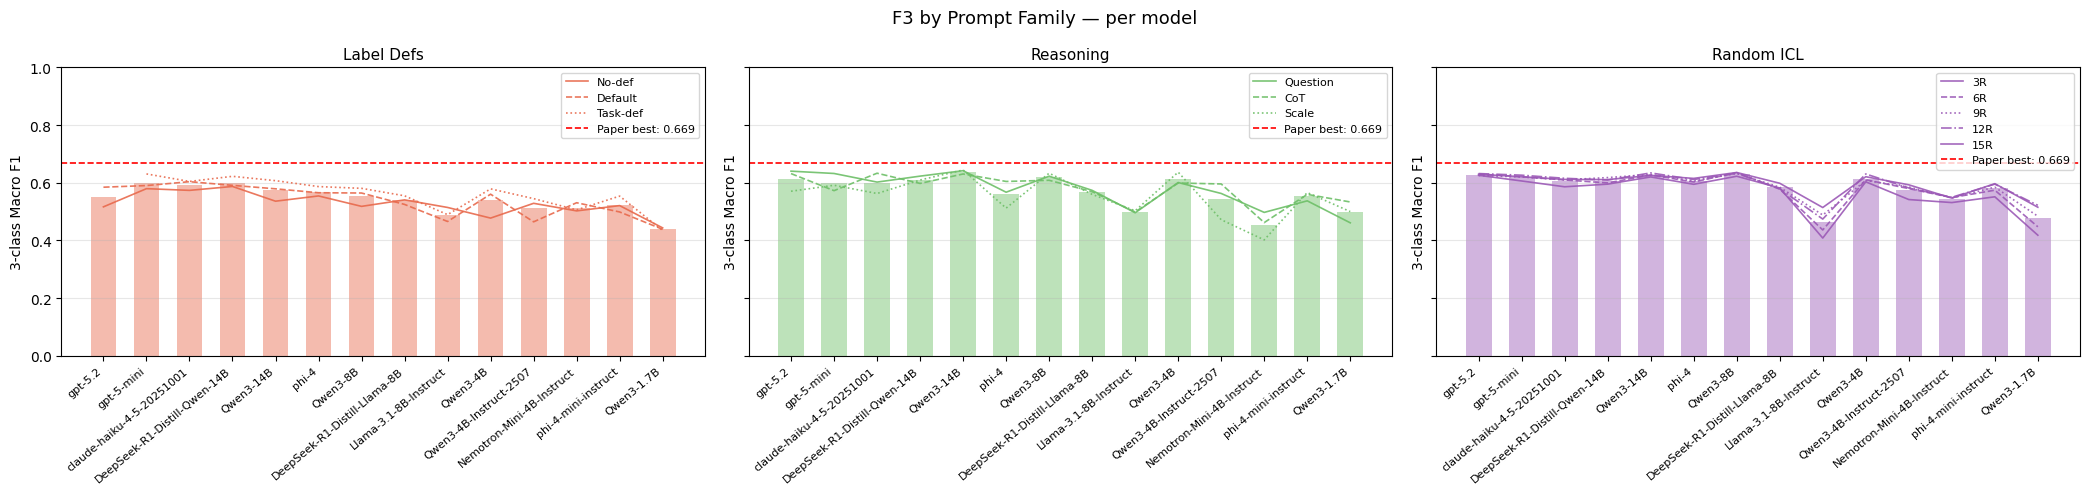

In [173]:
FAMILIES = OrderedDict([
    ("Label Defs", {
        "prompts": ["default_no_label_definitions", "default", "task_definition"],
        "labels":  ["No-def", "Default", "Task-def"],
        "color":   "#E8694C", "styles": ["-", "--", ":"],
    }),
    ("Reasoning", {
        "prompts": ["question", "cot", "task_definition_scale"],
        "labels":  ["Question", "CoT", "Scale"],
        "color":   "#6DBF67", "styles": ["-", "--", ":"],
    }),
    ("Random ICL", {
        "prompts": ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"],
        "labels":  ["3R","6R","9R","12R","15R"],
        "color":   "#9B59B6", "styles": ["-","--",":","-.","-"],
    }),
])

avail_models = _ordered_models(llm_df)
avail_model_labels = [m.split("/")[-1] if "/" in m else m for m in avail_models]
x = np.arange(len(avail_models))
bar_w = 0.6

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(7 * len(FAMILIES), 5), sharey=True)
fig.suptitle("F3 by Prompt Family — per model", fontsize=13)

for ax, (fam_name, fam) in zip(axes, FAMILIES.items()):
    fam_prompts = [p for p in fam["prompts"] if p in llm_df["prompt"].unique()]
    if not fam_prompts:
        ax.set_title(fam_name)
        continue

    means = [llm_df[(llm_df["model"] == m) & (llm_df["prompt"].isin(fam_prompts))]["3class_macro_f1"].mean()
             for m in avail_models]
    ax.bar(x, means, width=bar_w, color=fam["color"], alpha=0.45)

    for pj, prompt in enumerate(fam_prompts):
        ys = []
        for xi, model in enumerate(avail_models):
            row = llm_df[(llm_df["model"] == model) & (llm_df["prompt"] == prompt)]
            ys.append(row["3class_macro_f1"].values[0] if len(row) else float("nan"))
        ax.plot(x, ys, color=fam["color"],
                linestyle=fam["styles"][pj % len(fam["styles"])],
                linewidth=1.2, alpha=0.9,
                label=fam["labels"][pj])

    ax.axhline(BEST_PAPER_F3, color="red", linestyle="--", linewidth=1.2,
               label=f"Paper best: {BEST_PAPER_F3}")
    ax.set_title(fam_name, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(avail_model_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("3-class Macro F1")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 15: Per-domain Macro F1 Analysis

8 EZStance domains: **CE** (Covid Epidemic), **WE** (World Events), **EdC** (Education & Culture),
**EnC** (Entertainment & Consumption), **S** (Sports), **R** (Rights), **EP** (Environmental Protection), **P** (Politics).

In [174]:
gold_np = pd.read_csv(GOLD_CSV)
gold_np["gold"] = gold_np["stance_label_original"].apply(canonicalize)
gold_np["id"]   = gold_np["id"].astype(str)

domain_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2663"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_np[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) == 0:
            continue
        _, _, f, _ = precision_recall_fscore_support(
            sub["gold"], sub["pred"], labels=CLASSES, average=None, zero_division=0
        )
        domain_rows.append({
            "model": model, "prompt": prompt, "domain": domain,
            "macro_f1": f.mean(), "f_favor": f[0], "f_against": f[1], "f_none": f[2],
        })

domain_df = pd.DataFrame(domain_rows)
print(f"Loaded {len(domain_df)} model×prompt×domain rows")
print("\nMean macro F1 per domain (across all model×prompt):")
print(domain_df.groupby("domain")["macro_f1"].mean().reindex(DOMAIN_ORDER).round(3).to_string())

Loaded 1224 model×prompt×domain rows

Mean macro F1 per domain (across all model×prompt):
domain
CE     0.566
WE     0.534
EdC    0.577
EnC    0.541
S      0.551
R      0.552
EP     0.570
P      0.547


### Chart: Per-domain Macro F1 — each model, mean across prompts

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19372/1867072345.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))


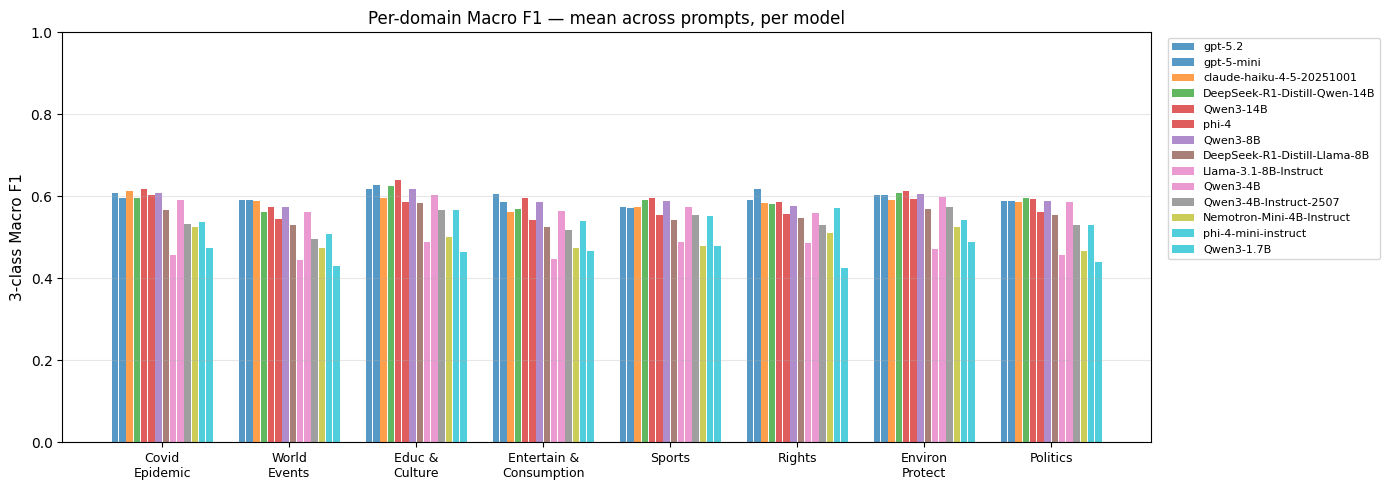

In [175]:
domain_mean = (
    domain_df.groupby(["model","domain"])["macro_f1"].mean().reset_index()
)
models_dom = _ordered_models(domain_df)
cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))
x = np.arange(len(DOMAIN_ORDER))
bar_w_dom  = 0.8 / max(len(models_dom), 1)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models_dom):
    mdf = domain_mean[domain_mean["model"] == model].set_index("domain")
    y = [mdf.loc[d, "macro_f1"] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
    short  = model.split("/")[-1] if "/" in model else model
    offset = (i - len(models_dom)/2 + 0.5) * bar_w_dom
    ax.bar(x + offset, y, width=bar_w_dom * 0.9, color=cmap_dom(i), alpha=0.75, label=short)

ax.set_xticks(x)
ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Per-domain Macro F1 — mean across prompts, per model", fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Per-domain per-class F1 — best prompt per model

Best prompt per model: {'DeepSeek-R1-Distill-Llama-8B': 'few_shot_15', 'DeepSeek-R1-Distill-Qwen-14B': 'question', 'Llama-3.1-8B-Instruct': 'default_no_label_definitions', 'Nemotron-Mini-4B-Instruct': 'few_shot_12', 'Qwen3-1.7B': 'cot', 'Qwen3-14B': 'task_definition_scale', 'Qwen3-4B-Instruct-2507': 'cot', 'Qwen3-4B': 'task_definition_scale', 'Qwen3-8B': 'few_shot_15', 'claude-haiku-4-5-20251001': 'cot', 'gpt-5-mini': 'question', 'gpt-5.2': 'question', 'phi-4-mini-instruct': 'few_shot_15', 'phi-4': 'few_shot_15'}


/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19372/648867095.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))


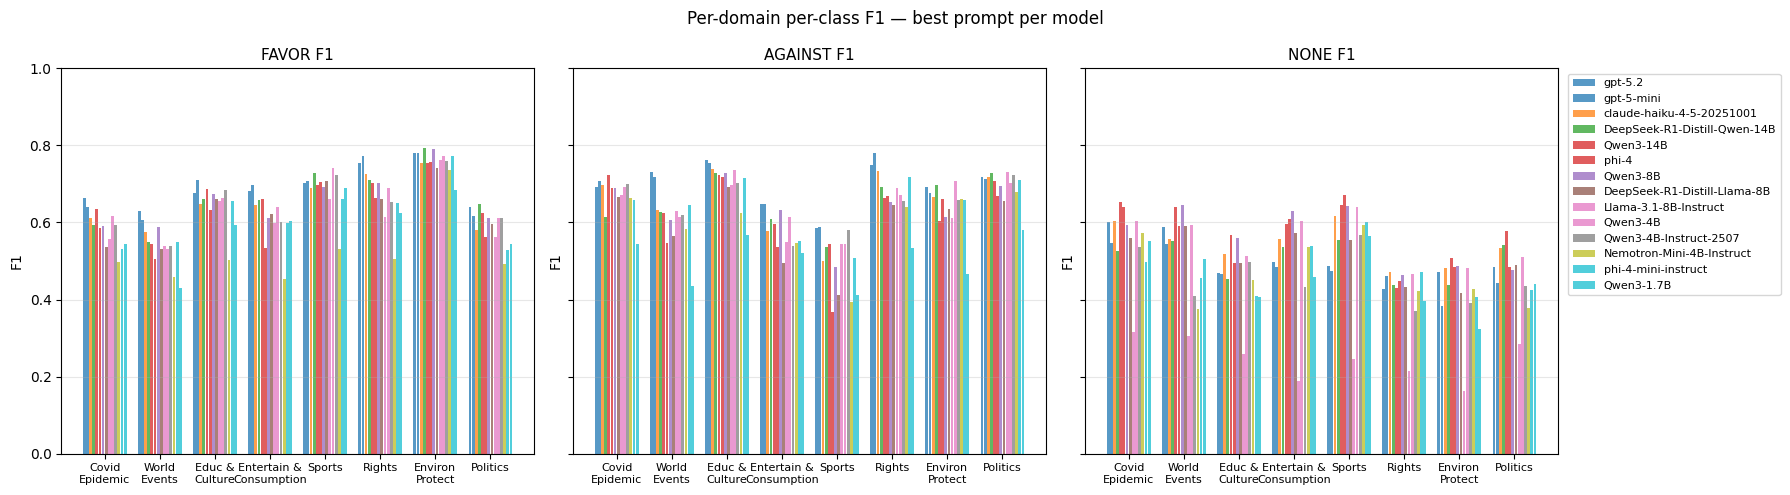

In [176]:
best_prompts_map = {
    m: llm_df.loc[llm_df[llm_df["model"] == m]["3class_macro_f1"].idxmax(), "prompt"]
    for m in llm_df["model"].unique()
}
print("Best prompt per model:", best_prompts_map)

selected = domain_df[domain_df.apply(
    lambda r: best_prompts_map.get(r["model"]) == r["prompt"], axis=1
)]
models_sel       = _ordered_models(selected)
model_labels_sel = [m.split("/")[-1] if "/" in m else m for m in models_sel]
cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Per-domain per-class F1 — best prompt per model", fontsize=12)

class_cols = [("f_favor","FAVOR"), ("f_against","AGAINST"), ("f_none","NONE")]
for col_idx, (cls_col, cls_name) in enumerate(class_cols):
    ax      = axes[col_idx]
    x       = np.arange(len(DOMAIN_ORDER))
    bar_w_s = 0.8 / max(len(models_sel), 1)
    for i, model in enumerate(models_sel):
        mdf = selected[selected["model"] == model].set_index("domain")
        y   = [mdf.loc[d, cls_col] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
        short  = model.split("/")[-1] if "/" in model else model
        offset = (i - len(models_sel)/2 + 0.5) * bar_w_s
        ax.bar(x + offset, y, width=bar_w_s * 0.9, color=cmap_sel(i), alpha=0.75, label=short)
    ax.set_xticks(x)
    ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"{cls_name} F1", fontsize=11)
    ax.set_ylabel("F1")
    ax.grid(axis="y", alpha=0.3)

axes[2].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Domain Ranking Table — which domains are hardest?

In [177]:
domain_ranking = (
    domain_df.groupby("domain")
    .agg(
        mean_f3       =("macro_f1",  "mean"),
        std_f3        =("macro_f1",  "std"),
        mean_f_favor  =("f_favor",   "mean"),
        mean_f_against=("f_against", "mean"),
        mean_f_none   =("f_none",    "mean"),
    )
    .reindex(DOMAIN_ORDER)
    .sort_values("mean_f3")
)
domain_ranking["domain_name"] = [
    DOMAIN_NAMES.get(d, d).replace("\n", " ") for d in domain_ranking.index
]
print("=== Domain Ranking Table (hardest → easiest) ===")
print(domain_ranking[
    ["domain_name","mean_f3","std_f3","mean_f_favor","mean_f_against","mean_f_none"]
].round(3).to_string())

=== Domain Ranking Table (hardest → easiest) ===
                    domain_name  mean_f3  std_f3  mean_f_favor  mean_f_against  mean_f_none
domain                                                                                     
WE                 World Events    0.534   0.061         0.533           0.580        0.487
EnC     Entertain & Consumption    0.541   0.061         0.610           0.532        0.482
P                      Politics    0.547   0.063         0.564           0.655        0.424
S                        Sports    0.551   0.053         0.674           0.485        0.495
R                        Rights    0.552   0.060         0.665           0.628        0.362
CE               Covid Epidemic    0.566   0.065         0.566           0.634        0.498
EP              Environ Protect    0.570   0.058         0.744           0.587        0.379
EdC              Educ & Culture    0.577   0.064         0.644           0.669        0.419


## Step 16: Per-domain Confusion Transition Heatmap

Same 6 transitions, broken out per domain. Values = mean transition rate across all prompts per model.

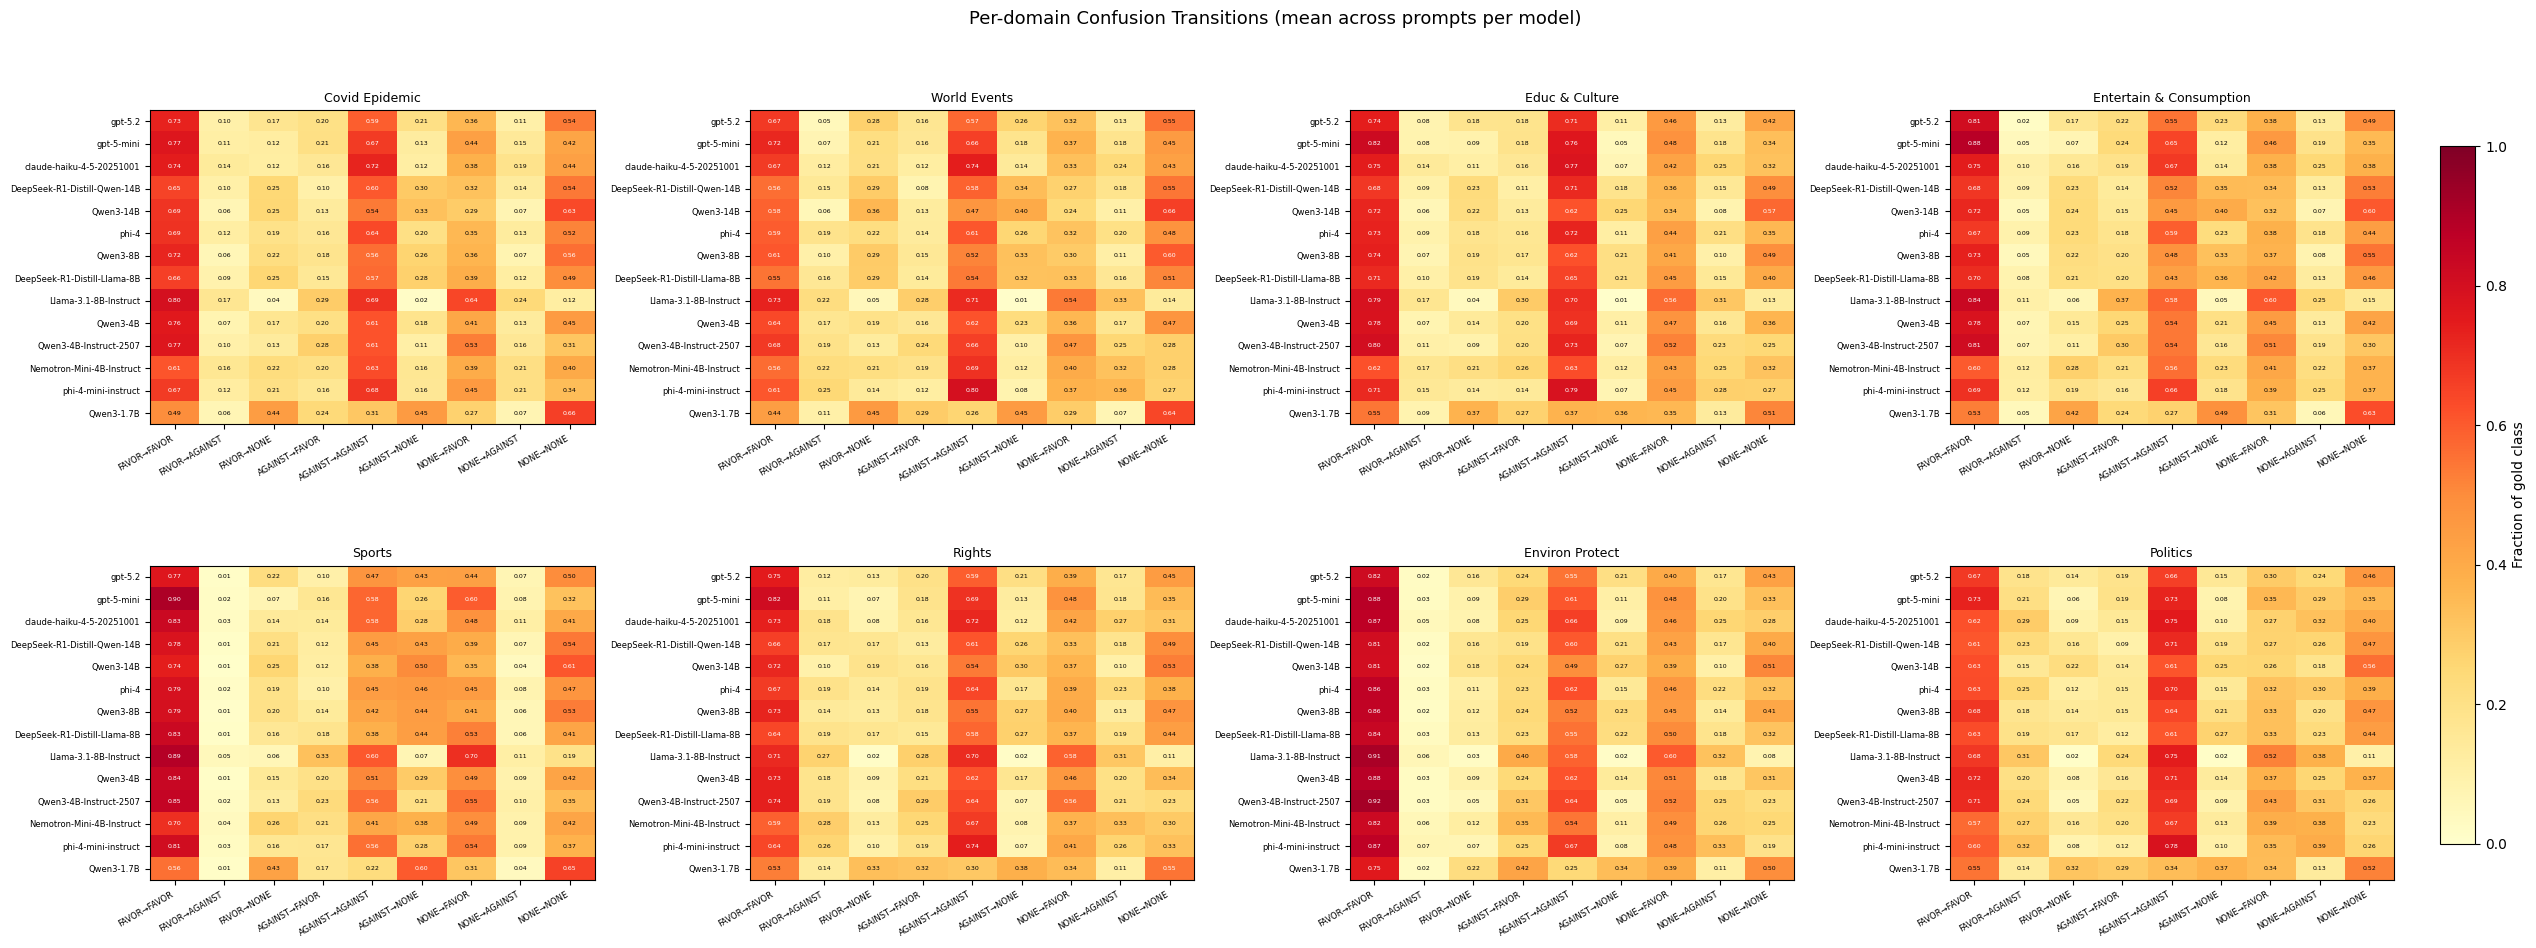

In [178]:
dom_cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2663"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_np[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES) & merged["gold"].isin(CLASSES)]
    short = model.split("/")[-1] if "/" in model else model

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) < 10:
            continue
        cm      = confusion_matrix(sub["gold"], sub["pred"], labels=CLASSES).astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sum, where=row_sum > 0)

        row = {"model": model, "model_short": short, "prompt": prompt, "domain": domain}
        for ri, tc in enumerate(CLASSES):
            for ci, pc in enumerate(CLASSES):
                row[f"{tc}→{pc}"] = cm_norm[ri, ci]
        dom_cm_rows.append(row)

dom_cm_df = pd.DataFrame(dom_cm_rows)

model_order_hm = _ordered_models(llm_df)

fig, axes = plt.subplots(2, 4, figsize=(30, 10),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.suptitle("Per-domain Confusion Transitions (mean across prompts per model)", fontsize=13)

for di, domain in enumerate(DOMAIN_ORDER):
    ax  = axes[di // 4][di % 4]
    sub = dom_cm_df[dom_cm_df["domain"] == domain]
    if len(sub) == 0:
        ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "))
        ax.axis("off")
        continue

    mean_trans = (
        sub.groupby("model")[KEY_TRANS].mean()
        .reindex([m for m in model_order_hm if m in sub["model"].unique()])
    )
    hmap     = mean_trans.values
    row_lbls = [m.split("/")[-1] if "/" in m else m for m in mean_trans.index]

    im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)
    ax.set_xticks(range(len(KEY_TRANS)))
    ax.set_xticklabels(KEY_TRANS, fontsize=6, rotation=30, ha="right")
    ax.set_yticks(range(len(row_lbls)))
    ax.set_yticklabels(row_lbls, fontsize=6)
    ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "), fontsize=9)

    for r in range(hmap.shape[0]):
        for c in range(hmap.shape[1]):
            val = hmap[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=4.5, color="black" if val < 0.55 else "white")

plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02,
             label="Fraction of gold class")
plt.show()

In [179]:
# ── Table for Per-domain Confusion Heatmap ───────────────────────────
print("=== Per-domain confusion transitions (mean across models and prompts) ===")
_dom_table = dom_cm_df.groupby(["domain", "model_short"])[KEY_TRANS].mean().round(3)
display(_dom_table)
print(_dom_table.to_csv())


=== Per-domain confusion transitions (mean across models and prompts) ===


FAVOR→FAVOR  FAVOR→AGAINST  FAVOR→NONE  \
domain model_short                                                            
CE     DeepSeek-R1-Distill-Llama-8B        0.660          0.086       0.254   
       DeepSeek-R1-Distill-Qwen-14B        0.649          0.102       0.248   
       Llama-3.1-8B-Instruct               0.797          0.168       0.036   
       Nemotron-Mini-4B-Instruct           0.611          0.164       0.225   
       Qwen3-1.7B                          0.495          0.064       0.441   
...                                          ...            ...         ...   
WE     claude-haiku-4-5-20251001           0.668          0.125       0.207   
       gpt-5-mini                          0.715          0.073       0.212   
       gpt-5.2                             0.674          0.049       0.276   
       phi-4                               0.594          0.187       0.219   
       phi-4-mini-instruct                 0.609          0.249       0.142   

                                     AGAINST→FAVOR  AGAINST→AGAINST  \
domain model_short                                                    
CE     DeepSeek-R1-Distill-Llama-8B          0.154            0.569   
       DeepSeek-R1-Distill-Qwen-14B          0.098            0.604   
       Llama-3.1-8B-Instruct                 0.292            0.690   
       Nemotron-Mini-4B-Instruct             0.205            0.632   
       Qwen3-1.7B                            0.239            0.308   
...                                            ...              ...   
WE     claude-haiku-4-5-20251001             0.119            0.739   
       gpt-5-mini                            0.160            0.658   
       gpt-5.2                               0.165            0.571   
       phi-4                                 0.136            0.607   
       phi-4-mini-instruct                   0.120            0.795   

                                     AGAINST→NONE  NONE→FAVOR  NONE→AGAINST  \
domain model_short                                                            
CE     DeepSeek-R1-Distill-Llama-8B         0.276       0.390         0.118   
       DeepSeek-R1-Distill-Qwen-14B         0.298       0.322         0.136   
       Llama-3.1-8B-Instruct                0.019       0.643         0.239   
       Nemotron-Mini-4B-Instruct            0.163       0.391         0.210   
       Qwen3-1.7B                           0.453       0.271         0.071   
...                                           ...         ...           ...   
WE     claude-haiku-4-5-20251001            0.142       0.331         0.238   
       gpt-5-mini                           0.182       0.370         0.178   
       gpt-5.2                              0.264       0.322         0.131   
       phi-4                                0.257       0.318         0.202   
       phi-4-mini-instruct                  0.085       0.373         0.361   

                                     NONE→NONE  
domain model_short                              
CE     DeepSeek-R1-Distill-Llama-8B      0.492  
       DeepSeek-R1-Distill-Qwen-14B      0.542  
       Llama-3.1-8B-Instruct             0.118  
       Nemotron-Mini-4B-Instruct         0.399  
       Qwen3-1.7B                        0.659  
...                                        ...  
WE     claude-haiku-4-5-20251001         0.431  
       gpt-5-mini                        0.452  
       gpt-5.2                           0.547  
       phi-4                             0.479  
       phi-4-mini-instruct               0.266  

[112 rows x 9 columns]

domain,model_short,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
CE,DeepSeek-R1-Distill-Llama-8B,0.66,0.086,0.254,0.154,0.569,0.276,0.39,0.118,0.492
CE,DeepSeek-R1-Distill-Qwen-14B,0.649,0.102,0.248,0.098,0.604,0.298,0.322,0.136,0.542
CE,Llama-3.1-8B-Instruct,0.797,0.168,0.036,0.292,0.69,0.019,0.643,0.239,0.118
CE,Nemotron-Mini-4B-Instruct,0.611,0.164,0.225,0.205,0.632,0.163,0.391,0.21,0.399
CE,Qwen3-1.7B,0.495,0.064,0.441,0.239,0.308,0.453,0.271,0.071,0.659
CE,Qwen3-14B,0.685,0.063,0.252,0.135,0.538,0.328,0.293,0.073,0.634
CE,Qwen3-4B,0.756,0.075,0.169,0.204,0.614,0.181,0.414,0.135,0.451
CE,Qwen3-4B-Instruct-2507,0.769,0.098,0.133,0.279,0.614,0.107,0.53,0.16,0.31
CE,Qwen3-8B,0.72,0.062,0.218,0.176,0.559,0.264,0.364,0.075,0.562
CE,claude-haiku-4-5-20251001,0.744,0.138,0.118,0.159,0.725,0.117,0.378,0.186,0.436
CE,gpt-5-mini,0.766,0.111,0.123,0.206,0.669,0.125,0.437,0.146,0.416
CE,gpt-5.2,0.728,0.1,0.172,0.202,0.592,0.20

## § Marginal Shift Analysis

Marginal shift per class = **predicted share − gold share** (percentage points), averaged equally across all prompt settings.

**Stratified bootstrap (1 000 iters):** documents are resampled *within each target/domain* independently, preserving per-stratum sample sizes and isolating within-topic variance. Whiskers show 2.5/97.5 percentiles.

[Shift] 14 models · 11 prompts · 2663 docs


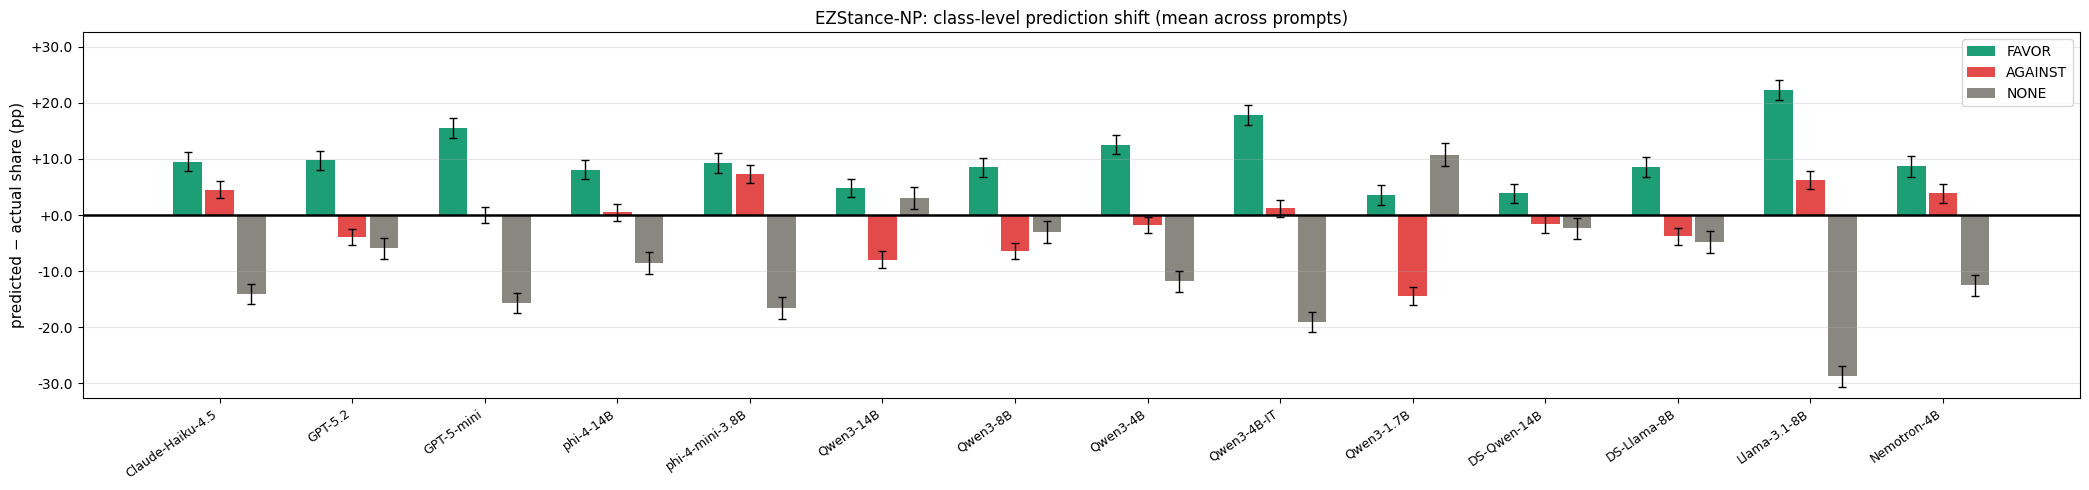

Saved → ../data_out/stance/stance_analysis/marginal_shift_ezstance-np.png

=== Table 1: Per-model Marginal Shifts (pp) — EZStance-NP ===
Model                                        F1  ΔFAVOR [95% CI]  ΔAGAINST [95% CI]  ΔNONE [95% CI]
────────────────────────────────────────────────────────────────────────────────────────────────────────────
claude-haiku-4-5-20251001                0.6010   +9.5 [ +7.8,+11.3]   +4.5 [ +3.0, +6.0]  -14.1 [-15.9,-12.3]
gpt-5.2                                  0.6084   +9.7 [ +8.0,+11.4]   -3.9 [ -5.4, -2.5]   -5.9 [ -7.8, -4.0]
gpt-5-mini                               0.6080  +15.5 [+13.8,+17.2]   +0.1 [ -1.5, +1.5]  -15.7 [-17.6,-13.8]
phi-4                                    0.5834   +8.0 [ +6.3, +9.7]   +0.5 [ -1.0, +2.0]   -8.5 [-10.5, -6.7]
phi-4-mini-instruct                      0.5578   +9.3 [ +7.5,+11.1]   +7.3 [ +5.7, +8.8]  -16.5 [-18.5,-14.7]
Qwen3-14B                                0.6156   +4.9 [ +3.3, +6.4]   -8.0 [ -9.4, -6.5]   +3.0 [ 

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
from sklearn.metrics import f1_score as _f1_score

# ── config ────────────────────────────────────────────────────────────────────
_DATASET   = "EZStance-NP"
_STRAT_COL = "domain"
_N_BOOT    = 1000
_SEED      = 42
_CLR       = {"FAVOR": "#1D9E75", "AGAINST": "#E24B4A", "NONE": "#888780"}
_OUT       = Path("../data_out/stance/stance_analysis")
_OUT.mkdir(parents=True, exist_ok=True)

# attach domain from gold CSV (query col contains noun phrases, not domain codes)
_gold_meta = pd.read_csv(GOLD_CSV)
_gold_meta['id'] = _gold_meta['id'].astype(str)
_id2dom = _gold_meta.set_index('id')['domain'].to_dict()

_canon = canonicalize   # canonicalise stance labels → FAVOR / AGAINST / NONE

# ── load all predictions ──────────────────────────────────────────────────────
_rows = []
for _fld in sorted(os.listdir(RESULTS_DIR)):
    if not _fld.startswith(PREFIX.rstrip("_")):
        continue
    _csv = RESULTS_DIR / _fld / "document_assignments.csv"
    if not _csv.exists():
        continue
    _stem = _fld[len(PREFIX):]
    _pts  = _stem.rsplit("_equal_", 1)
    if len(_pts) != 2:
        continue
    _m, _p = _pts
    if _p not in PROMPT_ORDER:
        continue
    _df = pd.read_csv(_csv)
    _df["model"]  = _m
    _df["prompt"] = _p
    _df["gold"]   = _df["original_stance"].apply(
        lambda x: _canon(str(x).upper().strip()) if pd.notna(x) else "")
    _df["pred"]   = _df["predicted_stance"].apply(
        lambda x: _canon(str(x).upper().strip()) if pd.notna(x) else "")
    _df = _df[_df["gold"].isin(CLASSES) & _df["pred"].isin(CLASSES)]
    _rows.append(_df[["doc_id", "gold", "pred", "model", "prompt"]])

if not _rows:
    raise RuntimeError("[Shift] No rows loaded — check RESULTS_DIR / PREFIX / PROMPT_ORDER")
_all   = pd.concat(_rows, ignore_index=True)
_all['doc_id'] = _all['doc_id'].astype(str)
_all['domain'] = _all['doc_id'].map(_id2dom)
_all = _all.dropna(subset=['domain'])
_mlist = list(_all["model"].unique())
_plist = [p for p in PROMPT_ORDER if p in _all["prompt"].unique()]
print(f"[Shift] {len(_mlist)} models · {len(_plist)} prompts · {_all['doc_id'].nunique()} docs")

# ── precompute numpy arrays for fast bootstrap ────────────────────────────────
_dmeta = (_all[["doc_id", _STRAT_COL, "gold"]]
           .drop_duplicates("doc_id").set_index("doc_id"))
_dlist = list(_dmeta.index)
_d2i   = {d: i for i, d in enumerate(_dlist)}
_nd    = len(_dlist)
_cidx  = {c: i for i, c in enumerate(CLASSES)}
_garr  = np.array([_cidx[_dmeta.loc[d, "gold"]] for d in _dlist], dtype=np.int8)

_MP = {}
for _m in _mlist:
    for _p in _plist:
        _s = _all[(_all["model"] == _m) & (_all["prompt"] == _p)][["doc_id", "pred"]]
        if _s.empty:
            continue
        _v = np.full(_nd, -1, dtype=np.int8)
        _ii = _s["doc_id"].map(_d2i)
        _cc = _s["pred"].map(_cidx)
        _ok = _ii.notna() & _cc.notna()
        _v[_ii[_ok].astype(int)] = _cc[_ok].astype(np.int8)
        _MP[(_m, _p)] = _v

def _shifts(w):
    """Return {model: {class: shift_pp}} using weight vector w (length n_docs)."""
    W = float(w.sum())
    g = np.array([((_garr == i).astype(float) @ w) / W for i in range(len(CLASSES))])
    out = {}
    for _m in _mlist:
        ps = []
        for _p in _plist:
            if (_m, _p) not in _MP:
                continue
            v = _MP[(_m, _p)]
            sh = np.array([(((v == i) & (v >= 0)).astype(float) @ w) / W
                            for i in range(len(CLASSES))])
            ps.append(sh - g)
        if ps:
            out[_m] = dict(zip(CLASSES, np.mean(ps, axis=0) * 100))
    return out

# ── point estimates ───────────────────────────────────────────────────────────
_pt = _shifts(np.ones(_nd))

# ── stratified bootstrap (1 000 iters) ────────────────────────────────────────
# Rationale: resampling within each target/domain independently preserves the
# per-stratum size, isolating within-topic variance rather than inflating CIs
# by conflating between-topic and within-topic variability.
_rng  = np.random.default_rng(_SEED)
_strt = {s: np.array([_d2i[d] for d in _dmeta[_dmeta[_STRAT_COL] == s].index])
         for s in _dmeta[_STRAT_COL].unique()}
_bt   = {m: {c: [] for c in CLASSES} for m in _mlist}
for _ in range(_N_BOOT):
    _w = np.zeros(_nd)
    for _ids in _strt.values():
        np.add.at(_w, _rng.choice(_ids, size=len(_ids), replace=True), 1.0)
    for _m, _cv in _shifts(_w).items():
        for _c in CLASSES:
            _bt[_m][_c].append(_cv[_c])

_ci = {m: {c: (float(np.percentile(_bt[m][c], 2.5)),
               float(np.percentile(_bt[m][c], 97.5)))
            for c in CLASSES}
       for m in _mlist}

# ── sort by mean macro F1 ─────────────────────────────────────────────────────
_f1m = {}
for _m in _mlist:
    _sc = [_f1_score(_s["gold"], _s["pred"], labels=CLASSES, average="macro", zero_division=0)
           for _p in _plist
           for _s in [_all[(_all["model"] == _m) & (_all["prompt"] == _p)]]
           if len(_s) > 0]
    _f1m[_m] = float(np.mean(_sc)) if _sc else 0.0
_FAMILY_MAP = {
    "claude-haiku-4-5-20251001":    "Closed",
    "gpt-5-mini":                   "Closed",
    "gpt-5.2":                      "Closed",
    "phi-4":                        "Phi",
    "phi-4-mini-instruct":          "Phi",
    "Qwen3-1.7B":                   "Qwen3",
    "Qwen3-4B":                     "Qwen3",
    "Qwen3-4B-Instruct-2507":       "Qwen3",
    "Qwen3-8B":                     "Qwen3",
    "Qwen3-14B":                    "Qwen3",
    "DeepSeek-R1-Distill-Llama-8B": "DeepSeek",
    "DeepSeek-R1-Distill-Qwen-14B": "DeepSeek",
    "Llama-3.1-8B-Instruct":        "Llama",
    "Nemotron-Mini-4B-Instruct":    "Nemotron",
}
_FAMILY_ORDER = ["Closed", "Phi", "Qwen3", "DeepSeek", "Llama", "Nemotron"]

# approx parameter count (B) - used to sort within each family, largest first
_SIZE_MAP = {
    "phi-4": 14, "phi-4-mini-instruct": 3.8,
    "Qwen3-1.7B": 1.7, "Qwen3-4B": 4, "Qwen3-4B-Instruct-2507": 4, "Qwen3-8B": 8, "Qwen3-14B": 14,
    "DeepSeek-R1-Distill-Llama-8B": 8, "DeepSeek-R1-Distill-Qwen-14B": 14,
    "Llama-3.1-8B-Instruct": 8,
    "Nemotron-Mini-4B-Instruct": 4,
}
# closed models have no disclosed size -> use an explicit fixed order instead
# (previously fell back to per-dataset F1, which put gpt-5-mini before gpt-5.2
# on some datasets and after it on others - now consistent across all three)
_CLOSED_ORDER = {
    "claude-haiku-4-5-20251001": 0,
    "gpt-5.2": 1,
    "gpt-5-mini": 2,
}
def _secondary_key(m):
    if m in _CLOSED_ORDER:
        return _CLOSED_ORDER[m]
    return -_SIZE_MAP.get(m, 0)

_ms = sorted(_mlist, key=lambda m: (
    _FAMILY_ORDER.index(_FAMILY_MAP.get(m, "Closed")),
    _secondary_key(m),
    -_f1m[m],
))

# ── grouped bar chart ─────────────────────────────────────────────────────────
_bw  = 0.24
_off = {"FAVOR": -_bw, "AGAINST": 0.0, "NONE": _bw}
_x   = np.arange(len(_ms))
_LABEL_MAP = {
    "DeepSeek-R1-Distill-Llama-8B": "DS-Llama-8B",
    "DeepSeek-R1-Distill-Qwen-14B": "DS-Qwen-14B",
    "Llama-3.1-8B-Instruct":        "Llama-3.1-8B",
    "phi-4":                        "phi-4-14B",
    "phi-4-mini-instruct":          "phi-4-mini-3.8B",
    "Nemotron-Mini-4B-Instruct":    "Nemotron-4B",
    "Qwen3-4B-Instruct-2507":       "Qwen3-4B-IT",
    "gpt-5-mini":                   "GPT-5-mini",
    "gpt-5.2":                      "GPT-5.2",
    "claude-haiku-4-5-20251001":    "Claude-Haiku-4.5",
}
_xl = [_LABEL_MAP.get(m, m) for m in _ms]

fig, ax = plt.subplots(figsize=(max(10, len(_ms) * 1.5), 5))
for _c in CLASSES:
    _h  = [_pt[m][_c] for m in _ms]
    _lo = [_pt[m][_c] - _ci[m][_c][0] for m in _ms]
    _hi = [_ci[m][_c][1] - _pt[m][_c] for m in _ms]
    ax.bar(_x + _off[_c], _h, width=_bw * 0.9, color=_CLR[_c], label=_c,
           yerr=[_lo, _hi], capsize=3, error_kw=dict(lw=1.0, capthick=1.0))

_ylim = max(abs(_pt[m][c]) + max(abs(_pt[m][c] - _ci[m][c][0]),
                                   abs(_ci[m][c][1] - _pt[m][c]))
            for m in _ms for c in CLASSES) + 2
ax.set_ylim(-_ylim, _ylim)
ax.axhline(0, color="black", linewidth=1.8)
ax.set_xticks(_x)
ax.set_xticklabels(_xl, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("predicted − actual share (pp)", fontsize=11)
ax.set_title(f"{_DATASET}: class-level prediction shift (mean across prompts)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}"))
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
_fp = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}.png"
plt.savefig(_fp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp}")

# ── Table 1 ───────────────────────────────────────────────────────────────────
_t1 = []
for _m in _ms:
    _r = {"model": _m, "macro_f1": round(_f1m[_m], 4)}
    for _c in CLASSES:
        _r[f"shift_{_c}"]   = round(_pt[_m][_c], 2)
        _r[f"ci_low_{_c}"]  = round(_ci[_m][_c][0], 2)
        _r[f"ci_high_{_c}"] = round(_ci[_m][_c][1], 2)
    _t1.append(_r)
pd.DataFrame(_t1).to_csv(
    _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}.csv", index=False)

print(f"\n=== Table 1: Per-model Marginal Shifts (pp) — {_DATASET} ===")
print(f"{'Model':<40} {'F1':>6}  " + "  ".join(f"Δ{c} [95% CI]" for c in CLASSES))
print("─" * 108)
for _r in _t1:
    def _fc(_c, r=_r):
        return f"{r[f'shift_{_c}']:+5.1f} [{r[f'ci_low_{_c}']:+5.1f},{r[f'ci_high_{_c}']:+5.1f}]"
    print(f"{_r['model']:<40} {_r['macro_f1']:>6.4f}  " + "  ".join(_fc(c) for c in CLASSES))
print(f"Saved → {_OUT / f'marginal_shift_{_DATASET.lower().replace(chr(32), chr(95))}.csv'}")

# ── Table 2: per target/domain ────────────────────────────────────────────────
_tgt_order = DOMAIN_ORDER
_t2 = []
for _tgt in _tgt_order:
    _td   = _dmeta[_dmeta[_STRAT_COL] == _tgt]
    _tsub = _all[_all[_STRAT_COL] == _tgt]
    _gn   = {c: int((_td["gold"] == c).sum()) for c in CLASSES}
    _tr   = {"target": _tgt, **{f"gold_n_{c}": _gn[c] for c in CLASSES}}
    for _c in CLASSES:
        if _gn[_c] < 50:
            _tr[f"mean_shift_{_c}"] = _tr[f"min_shift_{_c}"] = _tr[f"max_shift_{_c}"] = None
        else:
            _msh = []
            for _m in _ms:
                _mdf = _tsub[_tsub["model"] == _m]
                _psh = []
                for _p in _plist:
                    _pdf = _mdf[_mdf["prompt"] == _p]
                    if _pdf.empty:
                        continue
                    _n = len(_pdf)
                    _psh.append((_pdf["pred"] == _c).sum() / _n * 100 -
                                 (_pdf["gold"] == _c).sum() / _n * 100)
                if _psh:
                    _msh.append(float(np.mean(_psh)))
            if _msh:
                _tr[f"mean_shift_{_c}"] = round(float(np.mean(_msh)), 1)
                _tr[f"min_shift_{_c}"]  = round(float(np.min(_msh)),  1)
                _tr[f"max_shift_{_c}"]  = round(float(np.max(_msh)),  1)
            else:
                _tr[f"mean_shift_{_c}"] = _tr[f"min_shift_{_c}"] = _tr[f"max_shift_{_c}"] = None
    _t2.append(_tr)
pd.DataFrame(_t2).to_csv(
    _OUT / f"shift_per_target_{_DATASET.lower().replace(' ', '_')}.csv", index=False)

print(f"\n=== Table 2: Per-target Gold n + Mean Shift across Models ===")
print(f"{'Target':<36}" + "  ".join(f" N_{c:>6}  Δ{c}[min,max]" for c in CLASSES))
print("─" * 108)
for _r in _t2:
    def _gf(_c, r=_r):
        if r[f"mean_shift_{_c}"] is None:
            return f" {r[f'gold_n_{_c}']:>6}  {'—':>22}"
        ms, mn, mx = r[f"mean_shift_{_c}"], r[f"min_shift_{_c}"], r[f"max_shift_{_c}"]
        return f" {r[f'gold_n_{_c}']:>6}  {f'{ms:+.1f}[{mn:+.1f},{mx:+.1f}]':>22}"
    print(f"{str(_r['target']):<36}" + "  ".join(_gf(c) for c in CLASSES))
print(f"Saved → {_OUT / f'shift_per_target_{_DATASET.lower().replace(chr(32), chr(95))}.csv'}")

# ── summary line ──────────────────────────────────────────────────────────────
_neg = sum(1 for _m in _ms if _pt[_m]["AGAINST"] < 0)
_mna = float(np.mean([_pt[_m]["AGAINST"] for _m in _ms]))
print(f"\n{_neg}/{len(_ms)} models have negative AGAINST shift; "
      f"mean AGAINST shift = {_mna:+.2f} pp")

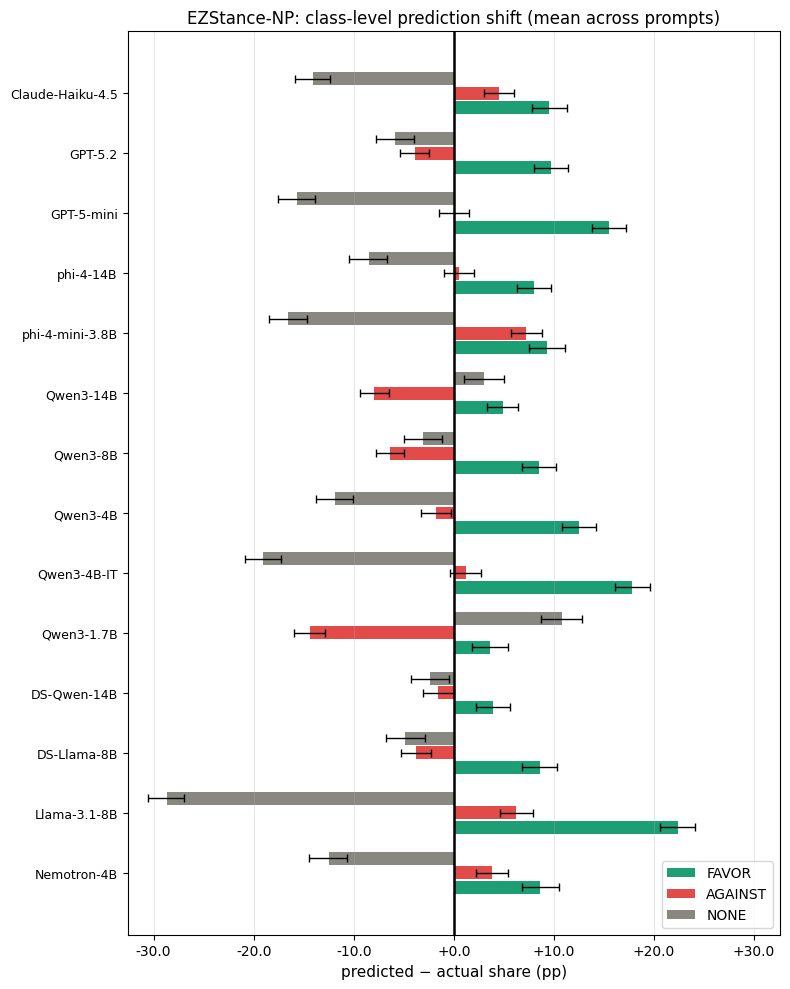

Saved → ../data_out/stance/stance_analysis/marginal_shift_ezstance-np_horizontal.png


In [181]:
# ── horizontal-bar alternative (same data/sort as the vertical chart above) ───
# Reuses _ms, _pt, _ci, _LABEL_MAP, _CLR, CLASSES, _DATASET, _OUT from the cell
# above - only the orientation changes, nothing is recomputed.
_bw_h  = 0.24
_off_h = {"FAVOR": _bw_h, "AGAINST": 0.0, "NONE": -_bw_h}
_y     = np.arange(len(_ms))

fig, ax = plt.subplots(figsize=(8, 10))
for _c in CLASSES:
    _h  = [_pt[m][_c] for m in _ms]
    _lo = [_pt[m][_c] - _ci[m][_c][0] for m in _ms]
    _hi = [_ci[m][_c][1] - _pt[m][_c] for m in _ms]
    ax.barh(_y + _off_h[_c], _h, height=_bw_h * 0.9, color=_CLR[_c], label=_c,
            xerr=[_lo, _hi], capsize=3, error_kw=dict(lw=1.0, capthick=1.0))

_xlim = max(abs(_pt[m][c]) + max(abs(_pt[m][c] - _ci[m][c][0]),
                                   abs(_ci[m][c][1] - _pt[m][c]))
            for m in _ms for c in CLASSES) + 2
ax.set_xlim(-_xlim, _xlim)
ax.axvline(0, color="black", linewidth=1.8)
ax.set_yticks(_y)
ax.set_yticklabels(_xl, fontsize=9)
ax.invert_yaxis()  # first model in _ms (Closed group, lead model) ends up at the top
ax.set_xlabel("predicted − actual share (pp)", fontsize=11)
ax.set_title(f"{_DATASET}: class-level prediction shift (mean across prompts)", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}"))
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
_fp_h = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}_horizontal.png"
plt.savefig(_fp_h, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp_h}")

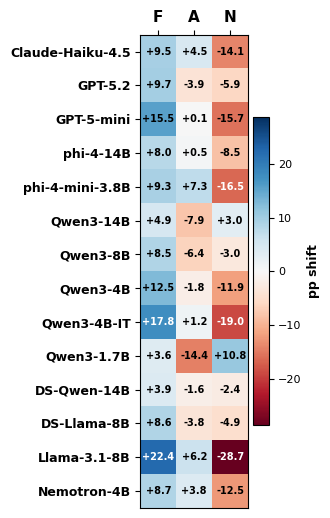

Saved → ../data_out/stance/stance_analysis/marginal_shift_ezstance-np_heatmap.png


In [185]:
# ── compact ACL-column heatmap (rows = models, cols = stance classes) ─────────
# blue = overprediction, red = underprediction; 3.3in wide = single ACL column
_hm_data = np.array([[_pt[m][c] for c in CLASSES] for m in _ms])
_xl_short = [_LABEL_MAP.get(m, m) for m in _ms]
_vmax = max(np.abs(_hm_data).max(), 1.0)
_n_models = len(_ms)
_fig_h = max(2.5, _n_models * 0.32 + 0.8)

fig, ax = plt.subplots(figsize=(3.3, _fig_h))
im = ax.imshow(_hm_data, cmap="RdBu", vmin=-_vmax, vmax=_vmax, aspect="auto")

_CLASS_SHORT = {"FAVOR": "F", "AGAINST": "A", "NONE": "N"}
ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels([_CLASS_SHORT.get(c, c) for c in CLASSES], fontsize=11, fontweight="bold")
ax.set_yticks(range(_n_models))
ax.set_yticklabels(_xl_short, fontsize=9, fontweight="bold")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

for i in range(_n_models):
    for j, _c in enumerate(CLASSES):
        val = _hm_data[i, j]
        color = "white" if abs(val) > _vmax * 0.55 else "black"
        ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                fontsize=7, fontweight="bold", color=color)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.12, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("pp shift", fontsize=9, fontweight="bold")


plt.tight_layout()
_fp_hm = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}_heatmap.png"
plt.savefig(_fp_hm, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp_hm}")

In [183]:
# ── marginal shift table ──────────────────────────────────────────────────────
_rows_tbl = []
for _m in _ms:
    _row = {"Model": _LABEL_MAP.get(_m, _m)}
    for _c in CLASSES:
        lo, hi = _ci[_m][_c]
        _row[_c] = f"{_pt[_m][_c]:+.1f} [{lo:+.1f},{hi:+.1f}]"
    _rows_tbl.append(_row)

_df_tbl = pd.DataFrame(_rows_tbl).set_index("Model")
_df_tbl.columns = ["FAVOR (pp)", "AGAINST (pp)", "NONE (pp)"]

_styled = _df_tbl.style.set_caption(f"{_DATASET}: Marginal Shift per Model (mean ± 95% CI)")\
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"),
                   ("padding-bottom", "6px")]},
        {"selector": "th",
         "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "center"),
                   ("background-color", "#f0f0f0"), ("padding", "4px 8px")]},
        {"selector": "td",
         "props": [("font-size", "11px"), ("text-align", "center"), ("padding", "3px 8px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#fafafa")]},
    ])\
    .apply(lambda col: [
        "color: #C0392B; font-weight:bold" if float(v.split()[0]) > 0
        else "color: #2471A3; font-weight:bold"
        for v in col
    ], axis=0)

from IPython.display import display
display(_styled)

,FAVOR (pp),AGAINST (pp),NONE (pp)
Model,,,
Claude-Haiku-4.5,"+9.5 [+7.8,+11.3]","+4.5 [+3.0,+6.0]","-14.1 [-15.9,-12.3]"
GPT-5.2,"+9.7 [+8.0,+11.4]","-3.9 [-5.4,-2.5]","-5.9 [-7.8,-4.0]"
GPT-5-mini,"+15.5 [+13.8,+17.2]","+0.1 [-1.5,+1.5]","-15.7 [-17.6,-13.8]"
phi-4-14B,"+8.0 [+6.4,+9.7]","+0.5 [-1.0,+2.0]","-8.5 [-10.5,-6.7]"
phi-4-mini-3.8B,"+9.3 [+7.5,+11.1]","+7.3 [+5.7,+8.8]","-16.5 [-18.5,-14.7]"
Qwen3-14B,"+4.9 [+3.3,+6.4]","-7.9 [-9.4,-6.5]","+3.0 [+1.0,+5.0]"
Qwen3-8B,"+8.5 [+6.8,+10.2]","-6.4 [-7.8,-5.0]","-3.0 [-4.9,-1.1]"
Qwen3-4B,"+12.5 [+10.8,+14.3]","-1.8 [-3.3,-0.3]","-11.9 [-13.8,-10.1]"
Qwen3-4B-IT,"+17.8 [+16.1,+19.6]","+1.2 [-0.3,+2.8]","-19.0 [-20.9,-17.2]"


In [184]:
# ── Appendix table: Macro F1 per model × prompt — EZStance ──────────────────
from IPython.display import display, HTML
import pandas as pd

_SHORT_NAME = {
    'Qwen3-1.7B':'Qwen3-1.7B','Qwen3-4B':'Qwen3-4B','Qwen3-4B-Instruct-2507':'Qwen3-4B-IT',
    'Qwen3-8B':'Qwen3-8B','Qwen3-14B':'Qwen3-14B',
    'DeepSeek-R1-Distill-Llama-8B':'DS-Llama-8B','DeepSeek-R1-Distill-Qwen-14B':'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':'Llama-3.1-8B','phi-4':'Phi-4','phi-4-mini-instruct':'Phi-4-mini',
    'Nemotron-Mini-4B-Instruct':'Nemotron-4B',
    'gpt-5-mini':'GPT-5-mini †','gpt-5.2':'GPT-5.2 †','claude-haiku-4-5-20251001':'Haiku-4.5 †',
}
_FAMILY = {
    'Qwen3-1.7B':'Qwen3','Qwen3-4B':'Qwen3','Qwen3-4B-Instruct-2507':'Qwen3',
    'Qwen3-8B':'Qwen3','Qwen3-14B':'Qwen3',
    'DeepSeek-R1-Distill-Llama-8B':'DeepSeek','DeepSeek-R1-Distill-Qwen-14B':'DeepSeek',
    'Llama-3.1-8B-Instruct':'Llama','phi-4':'Phi','phi-4-mini-instruct':'Phi',
    'Nemotron-Mini-4B-Instruct':'Nemotron',
    'gpt-5-mini':'Closed','gpt-5.2':'Closed','claude-haiku-4-5-20251001':'Closed',
}
_FAMILY_ORDER = ['Qwen3','DeepSeek','Llama','Phi','Nemotron','Closed']
_SIZE = {
    'Qwen3-1.7B':1.7,'Qwen3-4B':4,'Qwen3-4B-Instruct-2507':4.1,'Qwen3-8B':8,'Qwen3-14B':14,
    'DeepSeek-R1-Distill-Llama-8B':8,'DeepSeek-R1-Distill-Qwen-14B':14,
    'Llama-3.1-8B-Instruct':8,'phi-4':14,'phi-4-mini-instruct':3.8,
    'Nemotron-Mini-4B-Instruct':4,'gpt-5-mini':100,'gpt-5.2':101,'claude-haiku-4-5-20251001':102,
}
def _model_sort(m):
    fam = _FAMILY.get(m,'Other')
    fi  = _FAMILY_ORDER.index(fam) if fam in _FAMILY_ORDER else 99
    return (fi, _SIZE.get(m,0))

def _render_table(df_src, metric_col, prompt_order, prompt_labels, title,
                  baselines=None, exclude_prefix=None):
    from IPython.display import display, HTML
    import pandas as pd

    _df = df_src.copy()
    if exclude_prefix:
        _df = _df[~_df['prompt'].str.startswith(exclude_prefix)]
    _prompts = [p for p in prompt_order if p in _df['prompt'].unique()]
    _df = _df[_df['prompt'].isin(_prompts)]

    _pivot = _df.pivot_table(index='model', columns='prompt',
                             values=metric_col, aggfunc='mean')
    _pivot = _pivot.reindex(columns=[p for p in _prompts if p in _pivot.columns])
    _pivot.columns = [prompt_labels.get(c,c) for c in _pivot.columns]
    _pivot = _pivot.loc[sorted(_pivot.index, key=_model_sort)]
    _pivot.index = [_SHORT_NAME.get(m,m) for m in _pivot.index]

    _all_vals = list(_pivot.values.flatten())
    if baselines:
        _all_vals += [v for _,v in baselines]
    _best = max(x for x in _all_vals if not pd.isna(x))

    def _fmt(v, bold=True):
        if pd.isna(v): return '—'
        s = f'{v:.3f}'
        return f'<b>{s}</b>' if (bold and abs(v - _best) < 1e-5) else s

    ncols = len(_pivot.columns)
    th = lambda t, extra='': f'<th style="text-align:center;padding:3px 7px;font-size:10px;background:#f0f0f0{extra}">{t}</th>'

    col_hdrs = ''.join(th(c) for c in _pivot.columns)
    rows_html = []

    # ── baseline rows ──────────────────────────────────────────────────────────
    if baselines:
        rows_html.append(
            f'<tr><td colspan="{ncols+1}" style="background:#fff3cd;font-weight:bold;'
            f'font-style:italic;font-size:10px;padding:2px 8px">Supervised Baseline</td></tr>')
        for bname, bval in baselines:
            bcells = ''.join(
                f'<td style="text-align:center;padding:2px 7px;font-size:10px;'
                f'background:#fffbea">{_fmt(bval)}</td>' for _ in _pivot.columns)
            rows_html.append(
                f'<tr style="border-bottom:1px solid #ccc">'
                f'<td style="padding:2px 8px;font-size:10px;white-space:nowrap;'
                f'background:#fffbea"><i>{bname}</i></td>{bcells}</tr>')

    # ── model rows ─────────────────────────────────────────────────────────────
    _prev_fam = None
    for _mname, _row in _pivot.iterrows():
        _orig = next((k for k,v in _SHORT_NAME.items() if v==_mname), _mname)
        _fam  = _FAMILY.get(_orig,'Other')
        if _fam != _prev_fam:
            rows_html.append(
                f'<tr><td colspan="{ncols+1}" style="background:#e8e8e8;font-weight:bold;'
                f'font-style:italic;font-size:10px;padding:2px 8px">{_fam}</td></tr>')
            _prev_fam = _fam
        _cells = ''.join(
            f'<td style="text-align:center;padding:2px 7px;font-size:10px">{_fmt(_row[c])}</td>'
            for c in _pivot.columns)
        rows_html.append(
            f'<tr><td style="padding:2px 8px;font-size:10px;white-space:nowrap">{_mname}</td>{_cells}</tr>')

    html = (
        f'<table style="border-collapse:collapse;margin-bottom:24px">'
        f'<caption style="font-weight:bold;font-size:12px;text-align:left;padding-bottom:6px">{title}</caption>'
        f'<thead><tr style="border-top:2px solid #333;border-bottom:1px solid #888">'
        f'<th style="text-align:left;padding:3px 8px;font-size:10px">Model</th>{col_hdrs}</tr></thead>'
        f'<tbody>{"".join(rows_html)}</tbody>'
        f'<tfoot><tr><td colspan="{ncols+1}" style="font-size:9px;color:#666;padding:4px 8px;'
        f'border-top:1px solid #aaa">† Closed model (API). <b>Bold</b> = highest score in table.</td></tr></tfoot>'
        f'</table>'
    )
    display(HTML(html))
    print(_pivot.to_string(float_format='{:.3f}'.format))
    print()

_render_table(
    df_src       = llm_df,
    metric_col   = '3class_macro_f1',
    prompt_order = PROMPT_ORDER,
    prompt_labels= PROMPT_LABELS_CHART,
    title        = 'EZStance — 3-class Macro F1 per model × prompt',
    baselines    = [('BART-MNLI-ep fine-tuned (M→N)', BEST_PAPER_F3)],
)

              No-def  Default  Task-def  Question   CoT  Scale    3R    6R    9R   12R   15R
Qwen3-1.7B     0.443    0.438     0.434     0.461 0.533  0.500 0.418 0.447 0.484 0.522 0.515
Qwen3-4B       0.477    0.560     0.579     0.601 0.599  0.637 0.603 0.610 0.608 0.630 0.621
Qwen3-4B-IT    0.529    0.464     0.545     0.563 0.596  0.472 0.542 0.580 0.585 0.582 0.593
Qwen3-8B       0.518    0.564     0.580     0.623 0.608  0.633 0.622 0.635 0.632 0.633 0.635
Qwen3-14B      0.536    0.579     0.607     0.642 0.630  0.644 0.620 0.627 0.628 0.634 0.625
DS-Llama-8B    0.540    0.525     0.555     0.573 0.569  0.560 0.582 0.578 0.584 0.579 0.598
DS-Qwen-14B    0.587    0.591     0.622     0.623 0.597  0.609 0.595 0.599 0.618 0.609 0.611
Llama-3.1-8B   0.514    0.465     0.489     0.496 0.498  0.503 0.408 0.436 0.488 0.474 0.514
Phi-4-mini     0.521    0.499     0.553     0.537 0.559  0.566 0.551 0.574 0.585 0.595 0.597
Phi-4          0.554    0.565     0.587     0.567 0.604  0.512 0.594 0